# HHL + Iterative Refinement: Sensitivity Analysis

Sensitivity of HHL+IR convergence to **problem size** ($n$) and **condition number** ($\kappa$).
All experiments run on `AerSimulator` (statevector-exact).

In [1]:
from pathlib import Path
import pickle
import sys


def find_repo_root(start: Path | None = None) -> Path:
    p = (start or Path.cwd()).resolve()
    for d in (p, *p.parents):
        if (d / ".git").exists() or (d / "pyproject.toml").exists() or (d / "src").exists():
            return d
    return p


repo_root = find_repo_root()
print(repo_root)

src_dir = repo_root / "src"
if src_dir.exists() and str(src_dir) not in sys.path:
    sys.path.insert(0, str(src_dir))
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from qlsas.algorithms.hhl import HHL, ClassicalEigOracle, QuantumEigOracle, UnaryEigOracle
from qlsas.state_prep import DefaultStatePrep
from qlsas.readout import MeasureXReadout
from qlsas.solver import QuantumLinearSolver
from qlsas.refiner import Refiner
from linear_systems_problems.random_matrix_generator_v2 import generate_problem

from datetime import datetime
import numpy as np
import math
import matplotlib.pyplot as plt
from qiskit_aer import AerSimulator

%config InlineBackend.figure_format = "retina"

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 12,
    "axes.labelsize": 14,
    "axes.titlesize": 14,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 11,
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
})

/Users/adrianharkness/QCOL_COPT/HHL/QLSAs


In [2]:
n_values = [4,8,16] #[4, 8, 16, 32]
kappa_values = [10,30,50] #[5, 10, 15, 20, 25, 30]
num_seeds = 5 #10
max_iter = 20
precision = 1e-30  # run full iterations; apply convergence threshold at visualization time

# False: next cell loads `data/sensitivity_analysis.pkl` if present. True: re-run full grid and overwrite cache.
RERUN = False

oracle = ClassicalEigOracle()
backend = AerSimulator()


def run_single(n, kappa, seed):
    """Run one HHL+IR instance and return residuals, circuit metadata, and shot stats."""
    prob = generate_problem(n=n, cond_number=kappa, sparsity=0.5, seed=seed)
    A, b = prob["A"], prob["b"]
    A = A / np.linalg.norm(b)
    b = b / np.linalg.norm(b)

    hhl = HHL(
        num_qpe_qubits=3,
        eig_oracle=oracle,
    )
    solver = QuantumLinearSolver(
        qlsa=hhl,
        readout=MeasureXReadout(),
        backend=backend,
        target_successful_shots=1000,
        shots_per_batch=5000,
    )
    refiner = Refiner(A=A, b=b, solver=solver)
    result = refiner.refine(
        precision=precision,
        max_iter=max_iter,
        plot=False,
        verbose=False,
        open_session=False,
    )

    circuit_meta = []
    for circ in result["transpiled_circuits"]:
        circuit_meta.append({
            "depth": circ.depth(),
            "gate_count": circ.size(),
            "num_qubits": circ.num_qubits,
            "cx_count": circ.count_ops().get("cx", 0),
        })

    return {
        "residuals": result["residuals"],
        "circuit_meta": circuit_meta,
        "shot_stats": result.get("shot_stats", []),
        "total_iterations": result["total_iterations"],
    }

In [3]:
data_dir = repo_root / "data"
data_dir.mkdir(parents=True, exist_ok=True)
cache_path = data_dir / "sensitivity_analysis.pkl"


def _sensitivity_payload():
    return {
        "meta": {
            "n_values": n_values,
            "kappa_values": kappa_values,
            "num_seeds": num_seeds,
            "max_iter": max_iter,
            "precision": precision,
            "oracle": oracle,
        },
        "results": results,
    }


def _save_sensitivity_cache():
    with open(cache_path, "wb") as f:
        pickle.dump(_sensitivity_payload(), f)


if not RERUN:
    if not cache_path.exists():
        raise FileNotFoundError(
            f"No cache at {cache_path}. Set RERUN=True in the previous cell to run experiments."
        )
    with open(cache_path, "rb") as f:
        payload = pickle.load(f)
    meta = payload["meta"]
    n_values = meta["n_values"]
    kappa_values = meta["kappa_values"]
    num_seeds = meta["num_seeds"]
    max_iter = meta["max_iter"]
    precision = meta["precision"]
    oracle = meta["oracle"]
    results = payload["results"]
    print(f"Loaded {len(results)} runs from {cache_path} (RERUN=False; set RERUN=True to recompute).")
else:
    results = {}
    total = len(n_values) * len(kappa_values) * num_seeds
    count = 0

    for n in n_values:
        for kappa in kappa_values:
            for seed in range(num_seeds):
                count += 1
                print(f"[{count}/{total}] n={n}, kappa={kappa}, seed={seed}")
                results[(n, kappa, seed)] = run_single(n, kappa, seed)
                _save_sensitivity_cache()

    print(f"\nDone — {len(results)} runs stored.\nSaved to {cache_path}")

Loaded 45 runs from /Users/adrianharkness/QCOL_COPT/HHL/QLSAs/data/sensitivity_analysis.pkl (RERUN=False; set RERUN=True to recompute).


In [4]:
results[(8, 10, 0)]["circuit_meta"][0]["num_qubits"] 

7

In [5]:
def get_residuals(results, n, kappa, seed):
    """Extract the residuals list from a result entry."""
    entry = results[(n, kappa, seed)]
    return entry["residuals"] if isinstance(entry, dict) else entry


def get_log_residual_matrix(results, n, kappa, num_seeds, max_iter):
    """Return (num_seeds x max_iter) array of log10 residuals for a fixed (n, kappa)."""
    mat = np.full((num_seeds, max_iter), np.nan)
    for seed in range(num_seeds):
        res = get_residuals(results, n, kappa, seed)
        length = min(len(res), max_iter)
        mat[seed, :length] = np.log10(np.maximum(res[:length], 1e-16))
    return mat


def compute_convergence_rate(log_residuals_1d):
    """Fit slope of log10(residual) vs iteration via least-squares."""
    valid = ~np.isnan(log_residuals_1d)
    y = log_residuals_1d[valid]
    x = np.arange(len(log_residuals_1d))[valid]
    if len(x) < 2:
        return np.nan
    coeffs = np.polyfit(x, y, 1)
    return coeffs[0]


def iterations_to_threshold(residuals, threshold=1e-8):
    """Return first iteration where residual <= threshold, or len(residuals) if never reached."""
    for i, r in enumerate(residuals):
        if r <= threshold:
            return i
    return len(residuals)


def get_circuit_meta_matrix(results, n, kappa, num_seeds, max_iter, field="gate_count"):
    """Return (num_seeds x max_iter) array of a circuit metadata field."""
    mat = np.full((num_seeds, max_iter), np.nan)
    for seed in range(num_seeds):
        entry = results[(n, kappa, seed)]
        if not isinstance(entry, dict) or "circuit_meta" not in entry:
            continue
        meta = entry["circuit_meta"]
        for i, m in enumerate(meta[:max_iter]):
            mat[seed, i] = m[field]
    return mat


def get_success_prob_matrix(results, n, kappa, num_seeds, max_iter):
    """Return (num_seeds x max_iter) array of per-iteration post-selection success probabilities."""
    mat = np.full((num_seeds, max_iter), np.nan)
    for seed in range(num_seeds):
        entry = results[(n, kappa, seed)]
        if not isinstance(entry, dict) or "shot_stats" not in entry:
            continue
        stats = entry["shot_stats"]
        for i, s in enumerate(stats[:max_iter]):
            if s.get("success_probability") is not None:
                mat[seed, i] = s["success_probability"]
    return mat


def get_total_shots_matrix(results, n, kappa, num_seeds, max_iter):
    """Return (num_seeds x max_iter) array of total shots submitted per iteration."""
    mat = np.full((num_seeds, max_iter), np.nan)
    for seed in range(num_seeds):
        entry = results[(n, kappa, seed)]
        if not isinstance(entry, dict) or "shot_stats" not in entry:
            continue
        stats = entry["shot_stats"]
        for i, s in enumerate(stats[:max_iter]):
            if s.get("total_shots_submitted") is not None:
                mat[seed, i] = s["total_shots_submitted"]
    return mat

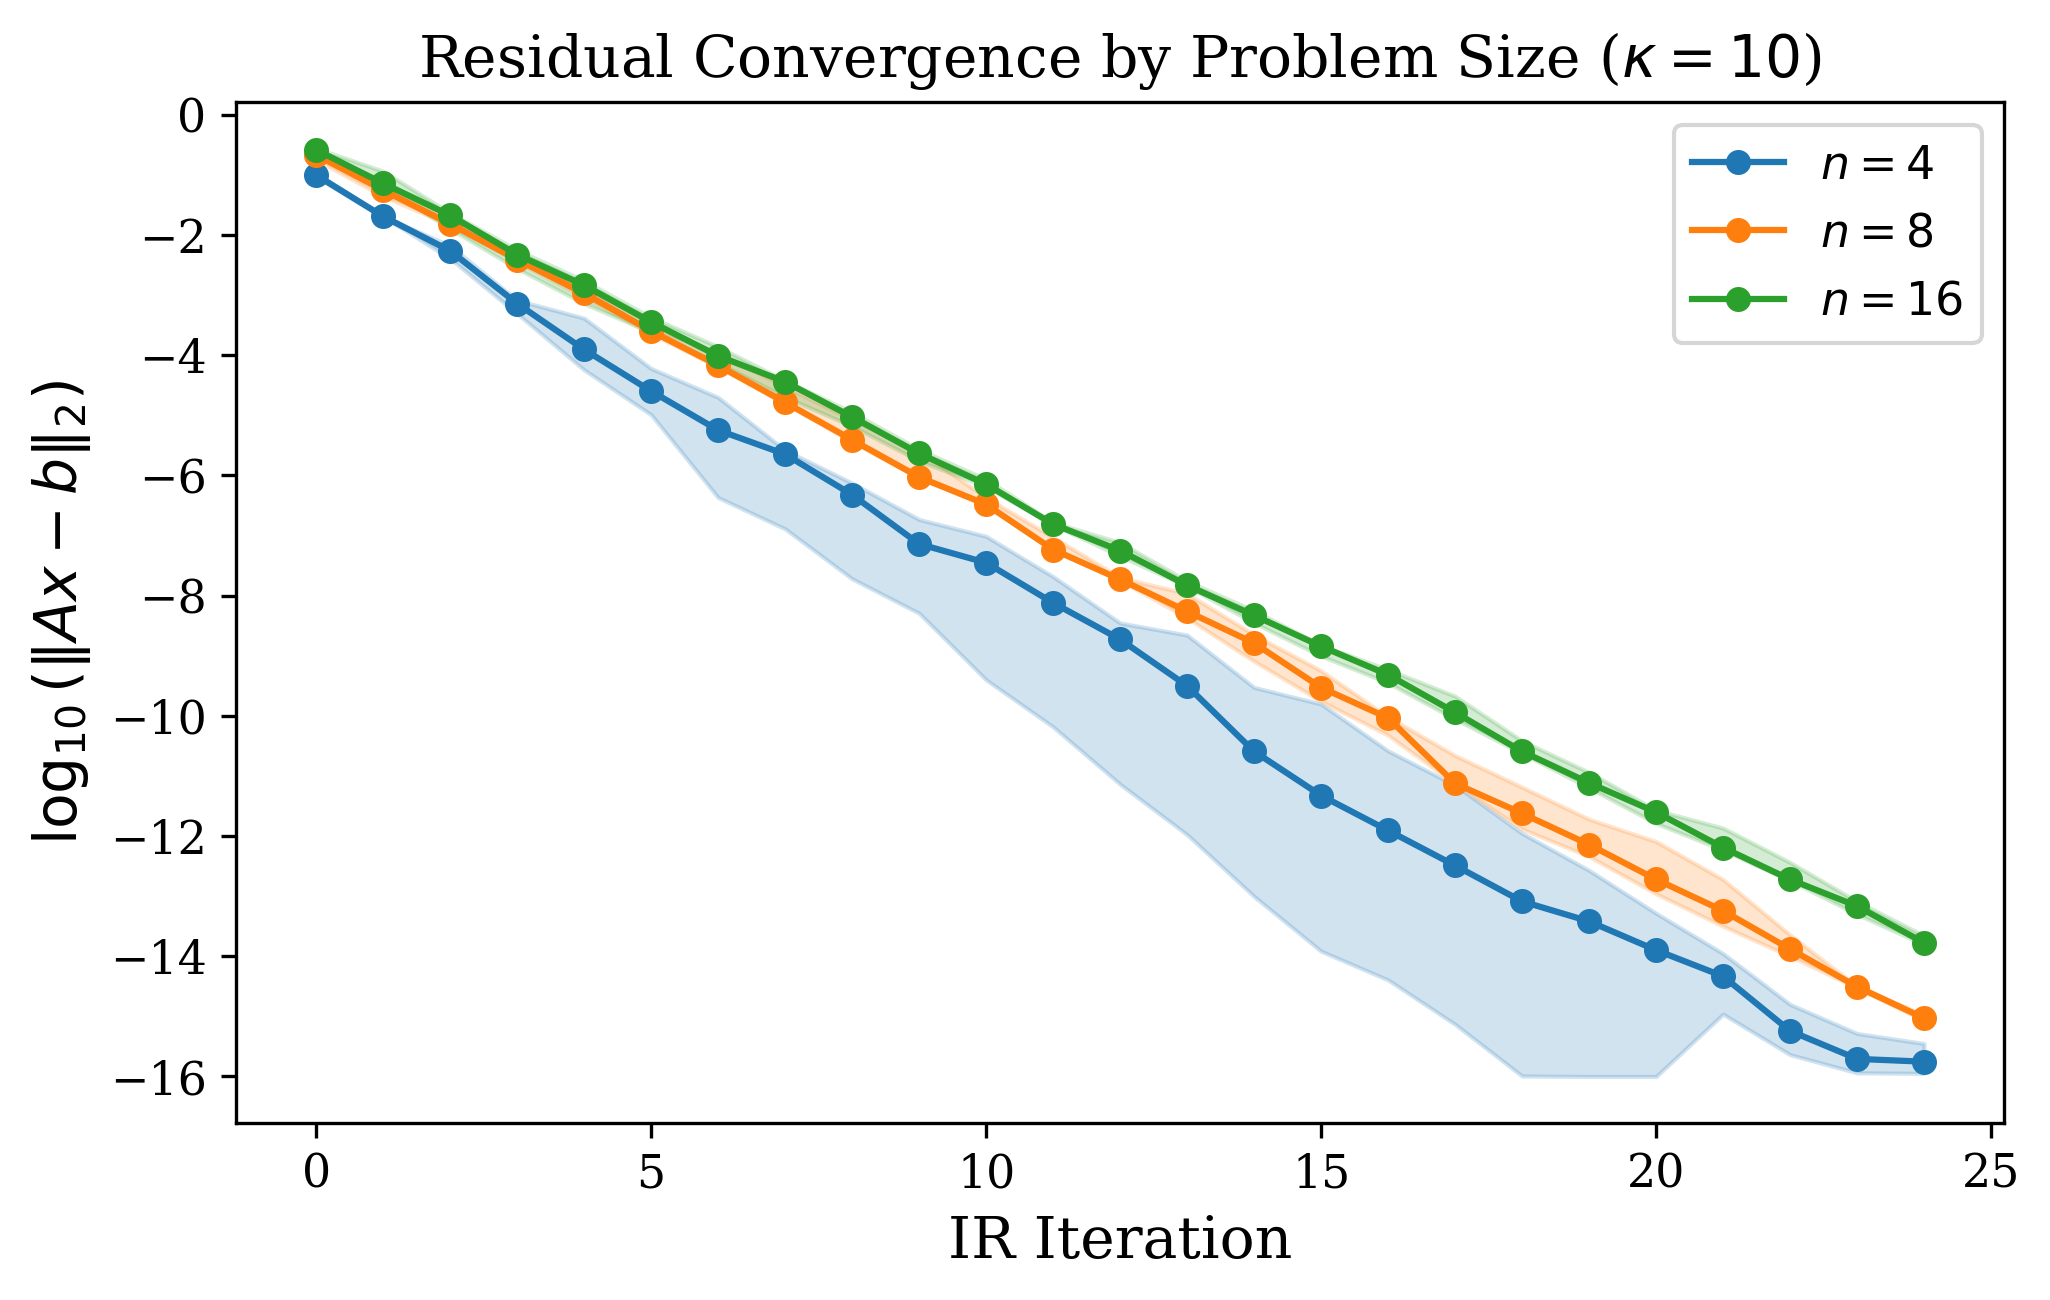

In [6]:
fig, ax = plt.subplots(figsize=(7, 4.5))

fixed_kappa = 10
size_subset = [4, 8, 16]

for n in size_subset:
    mat = get_log_residual_matrix(results, n, fixed_kappa, num_seeds, max_iter)
    median = np.nanmedian(mat, axis=0)
    q25 = np.nanpercentile(mat, 25, axis=0)
    q75 = np.nanpercentile(mat, 75, axis=0)
    iters = np.arange(max_iter)

    color = ax.plot(iters, median, "o-", label=f"$n = {n}$", markersize=5)[0].get_color()
    ax.fill_between(iters, q25, q75, alpha=0.2, color=color)

ax.set_xlabel("IR Iteration")
ax.set_ylabel(r"$\log_{10}(\|Ax - b\|_2)$")
ax.set_title(rf"Residual Convergence by Problem Size ($\kappa = {fixed_kappa}$)")
ax.legend()
plt.tight_layout()
plt.savefig(
    f"../data/sensitivity_size_bands_kappa{fixed_kappa}_{backend.name}_{datetime.now().strftime('%Y%m%d_%H%M%S')}.pdf"
)
plt.show()

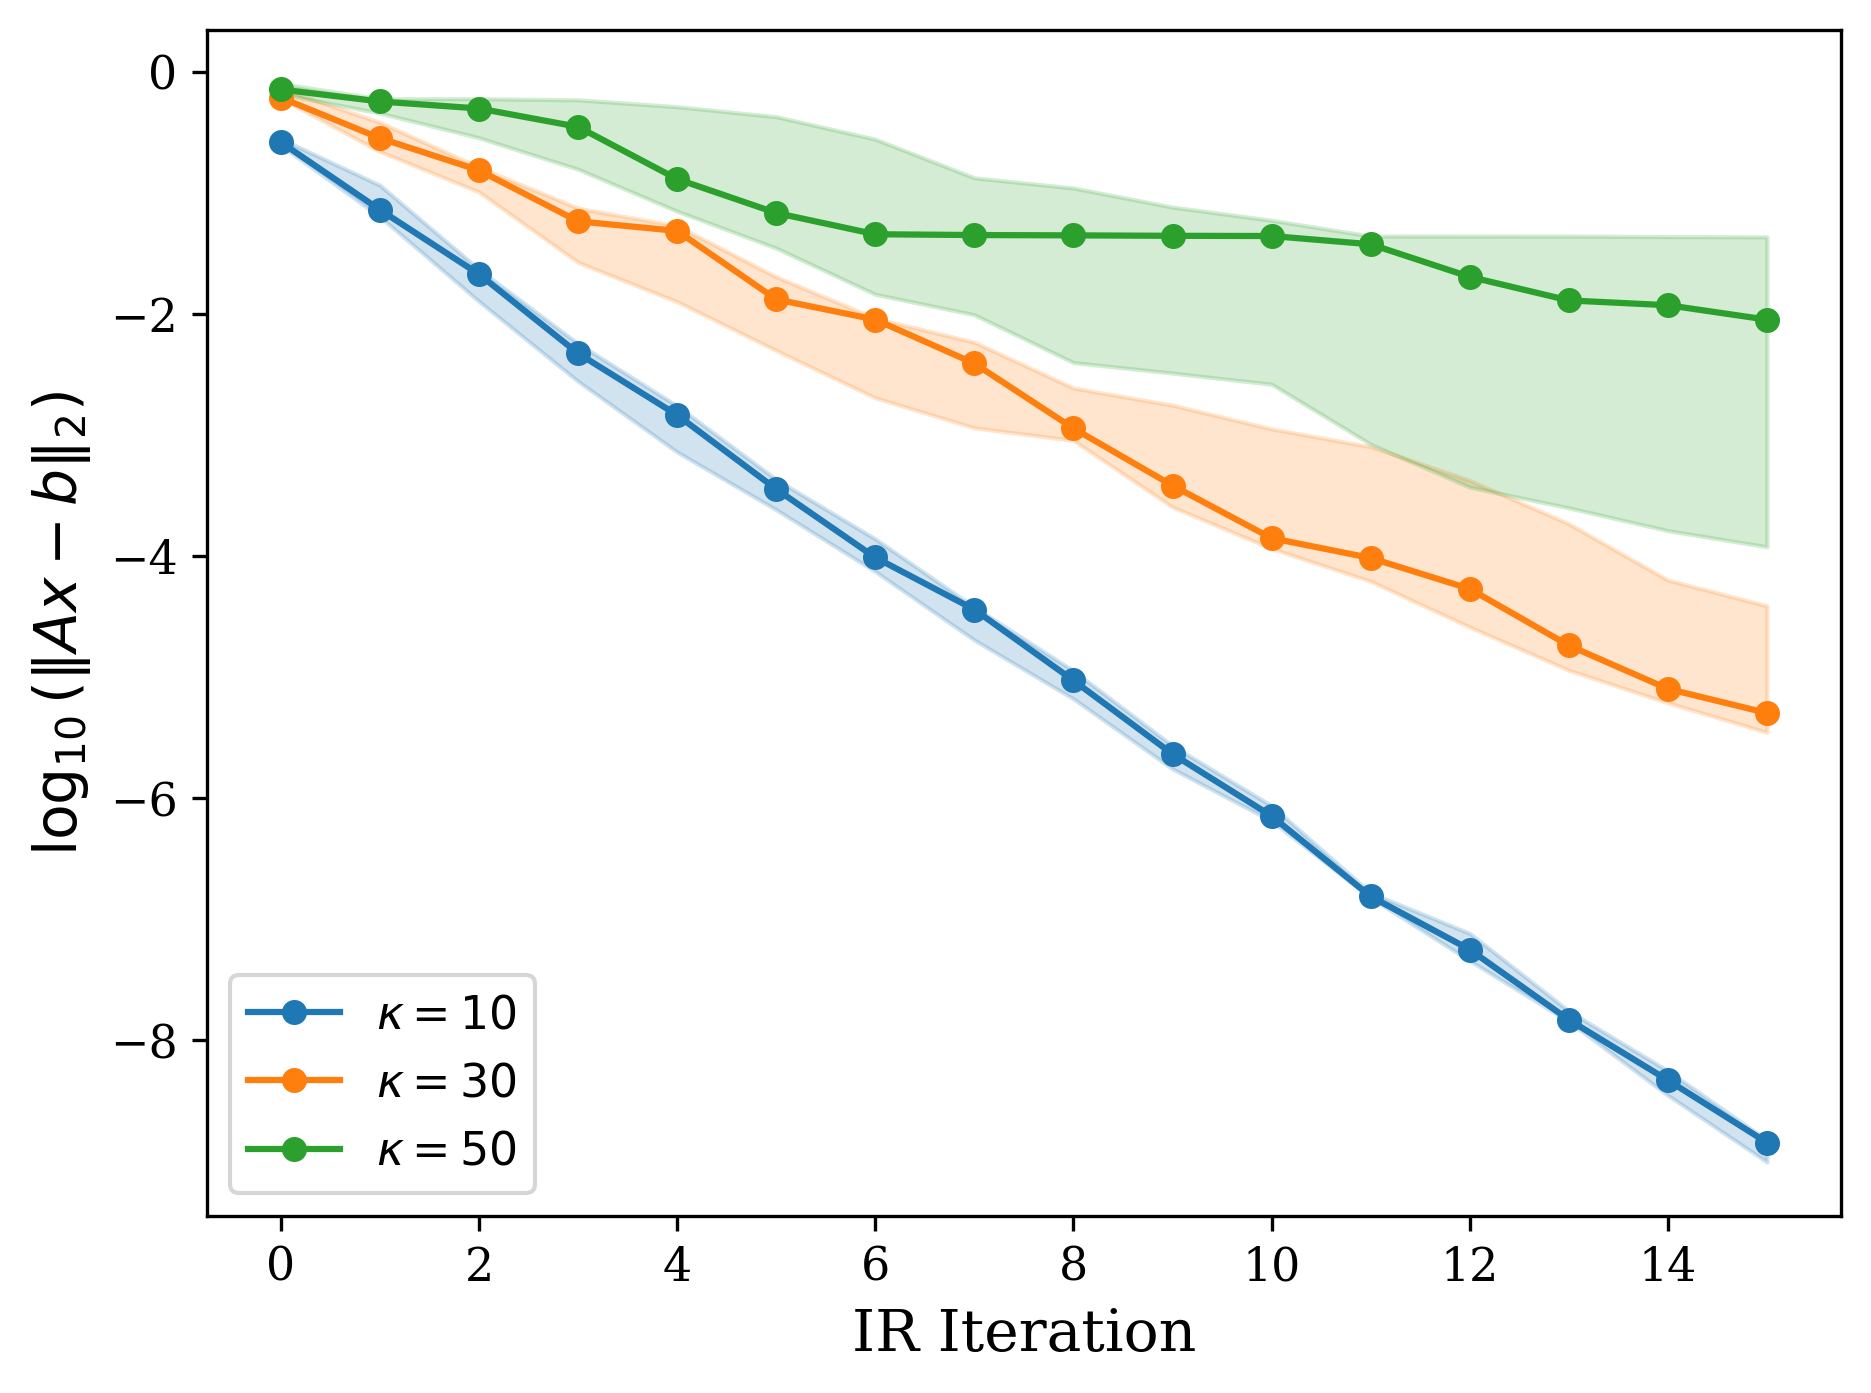

In [7]:
fig, ax = plt.subplots()

fixed_n = 16
kappa_subset = [10, 30, 50]

for kappa in kappa_subset:
    mat = get_log_residual_matrix(results, fixed_n, kappa, num_seeds, max_iter)
    median = np.nanmedian(mat, axis=0)
    q25 = np.nanpercentile(mat, 25, axis=0)
    q75 = np.nanpercentile(mat, 75, axis=0)
    iters = np.arange(max_iter)

    color = ax.plot(iters[:16], median[:16], "o-", label=rf"$\kappa = {kappa}$", markersize=5)[0].get_color()
    ax.fill_between(iters[:16], q25[:16], q75[:16], alpha=0.2, color=color)

ax.set_xlabel("IR Iteration")
ax.set_ylabel(r"$\log_{10}(\|Ax - b\|_2)$")
# ax.set_title(rf"Residual Convergence by Condition Number ($n = {fixed_n}$)")
ax.legend()
plt.tight_layout()
plt.savefig(
    f"../data/sensitivity_kappa_bands_n{fixed_n}_{backend.name}_{datetime.now().strftime('%Y%m%d_%H%M%S')}.pdf"
)
plt.show()

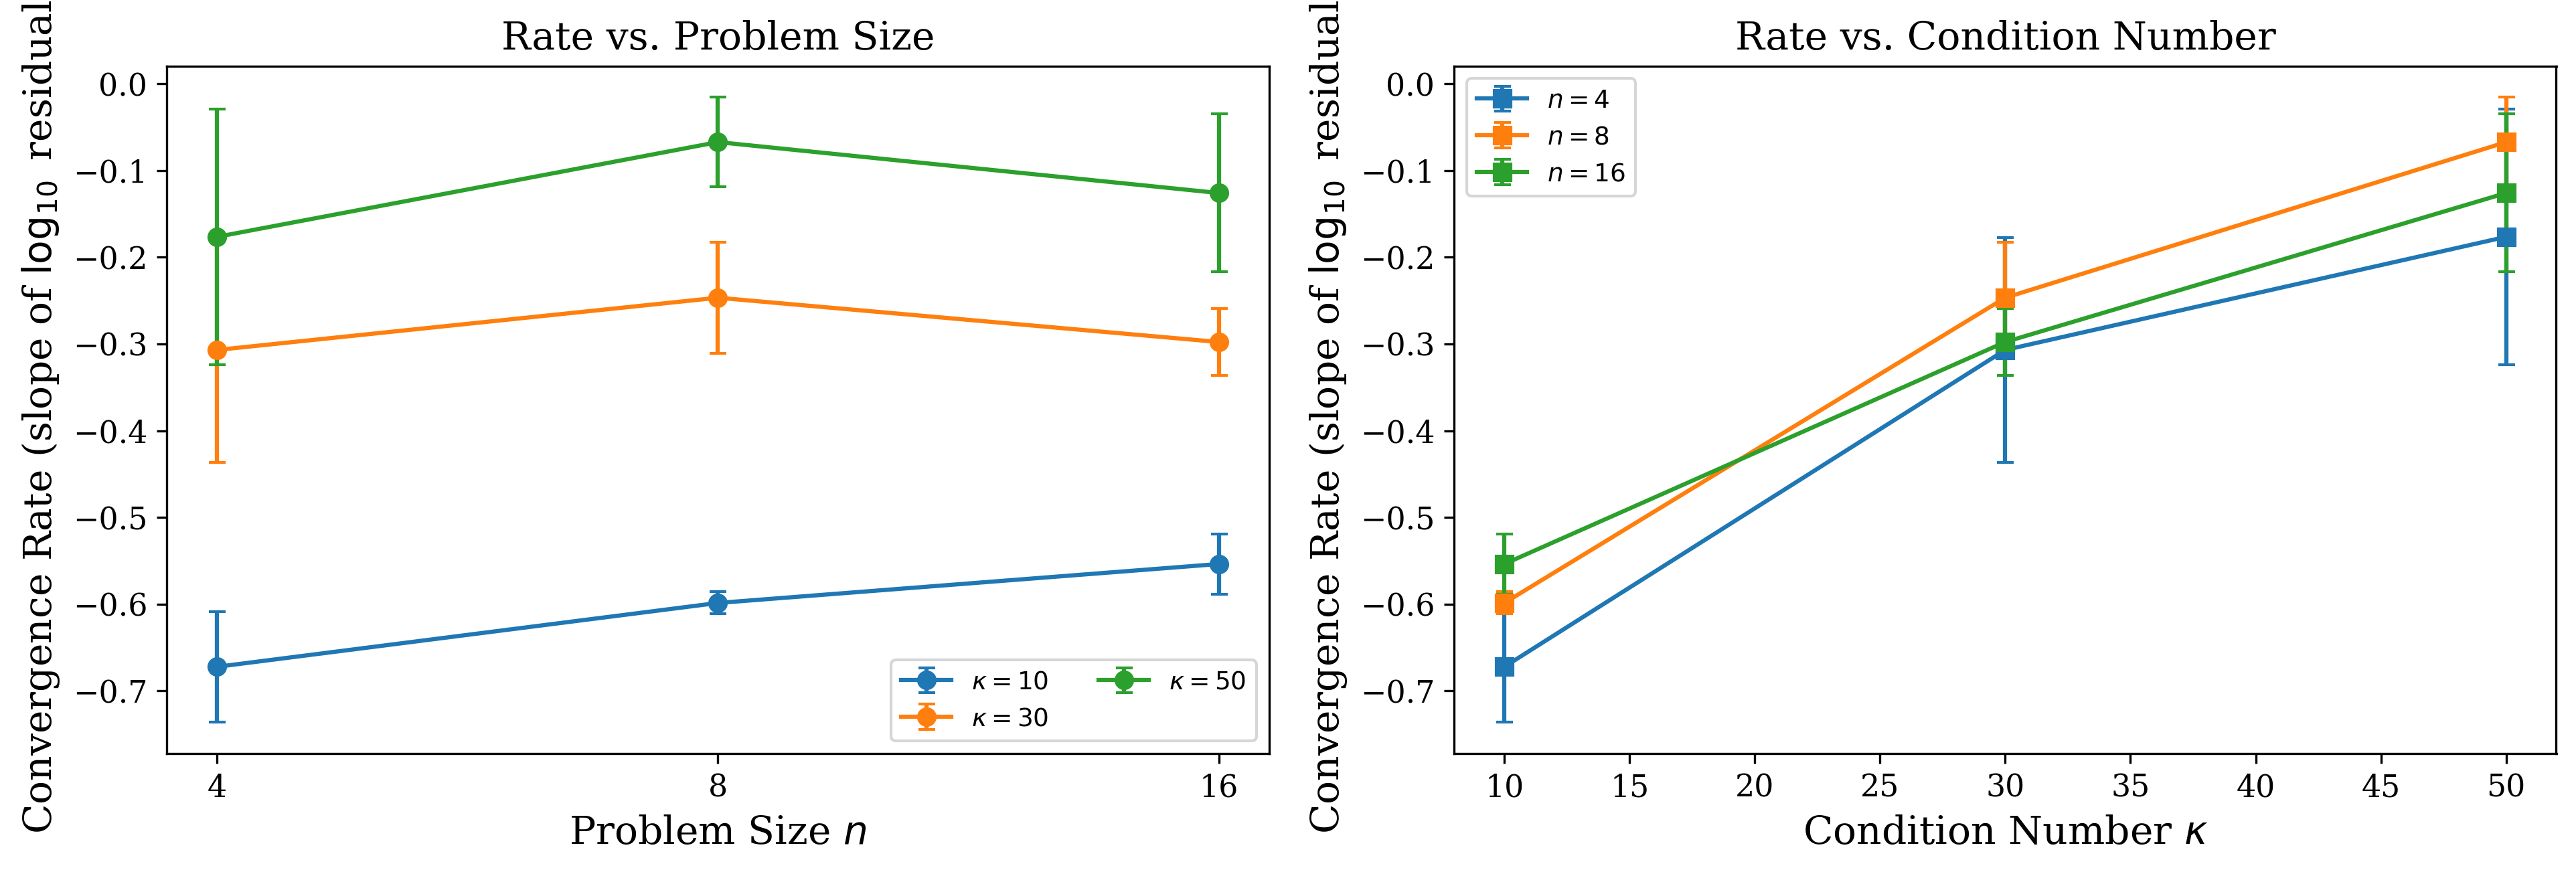

In [8]:
rates = np.full((len(n_values), len(kappa_values), num_seeds), np.nan)

for i, n in enumerate(n_values):
    for j, kappa in enumerate(kappa_values):
        mat = get_log_residual_matrix(results, n, kappa, num_seeds, max_iter)
        for s in range(num_seeds):
            rates[i, j, s] = compute_convergence_rate(mat[s])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))

# Left: convergence rate vs n, one line per kappa
for j, kappa in enumerate(kappa_values):
    mean_rate = np.nanmean(rates[:, j, :], axis=1)
    std_rate = np.nanstd(rates[:, j, :], axis=1)
    ax1.errorbar(
        n_values, mean_rate, yerr=std_rate,
        fmt="o-", capsize=3, label=rf"$\kappa = {kappa}$",
    )

ax1.set_xlabel("Problem Size $n$")
ax1.set_ylabel("Convergence Rate (slope of $\\log_{10}$ residual)")
ax1.set_title("Rate vs. Problem Size")
ax1.set_xscale("log", base=2)
ax1.set_xticks(n_values)
ax1.set_xticklabels([str(v) for v in n_values])
ax1.legend(fontsize=9, ncol=2)

# Right: convergence rate vs kappa, one line per n
for i, n in enumerate(n_values):
    mean_rate = np.nanmean(rates[i, :, :], axis=1)
    std_rate = np.nanstd(rates[i, :, :], axis=1)
    ax2.errorbar(
        kappa_values, mean_rate, yerr=std_rate,
        fmt="s-", capsize=3, label=f"$n = {n}$",
    )

ax2.set_xlabel(r"Condition Number $\kappa$")
ax2.set_ylabel("Convergence Rate (slope of $\\log_{10}$ residual)")
ax2.set_title("Rate vs. Condition Number")
ax2.legend(fontsize=9)

plt.tight_layout()
plt.savefig(
    f"../data/sensitivity_convergence_rates_{backend.name}_{datetime.now().strftime('%Y%m%d_%H%M%S')}.pdf"
)
plt.show()

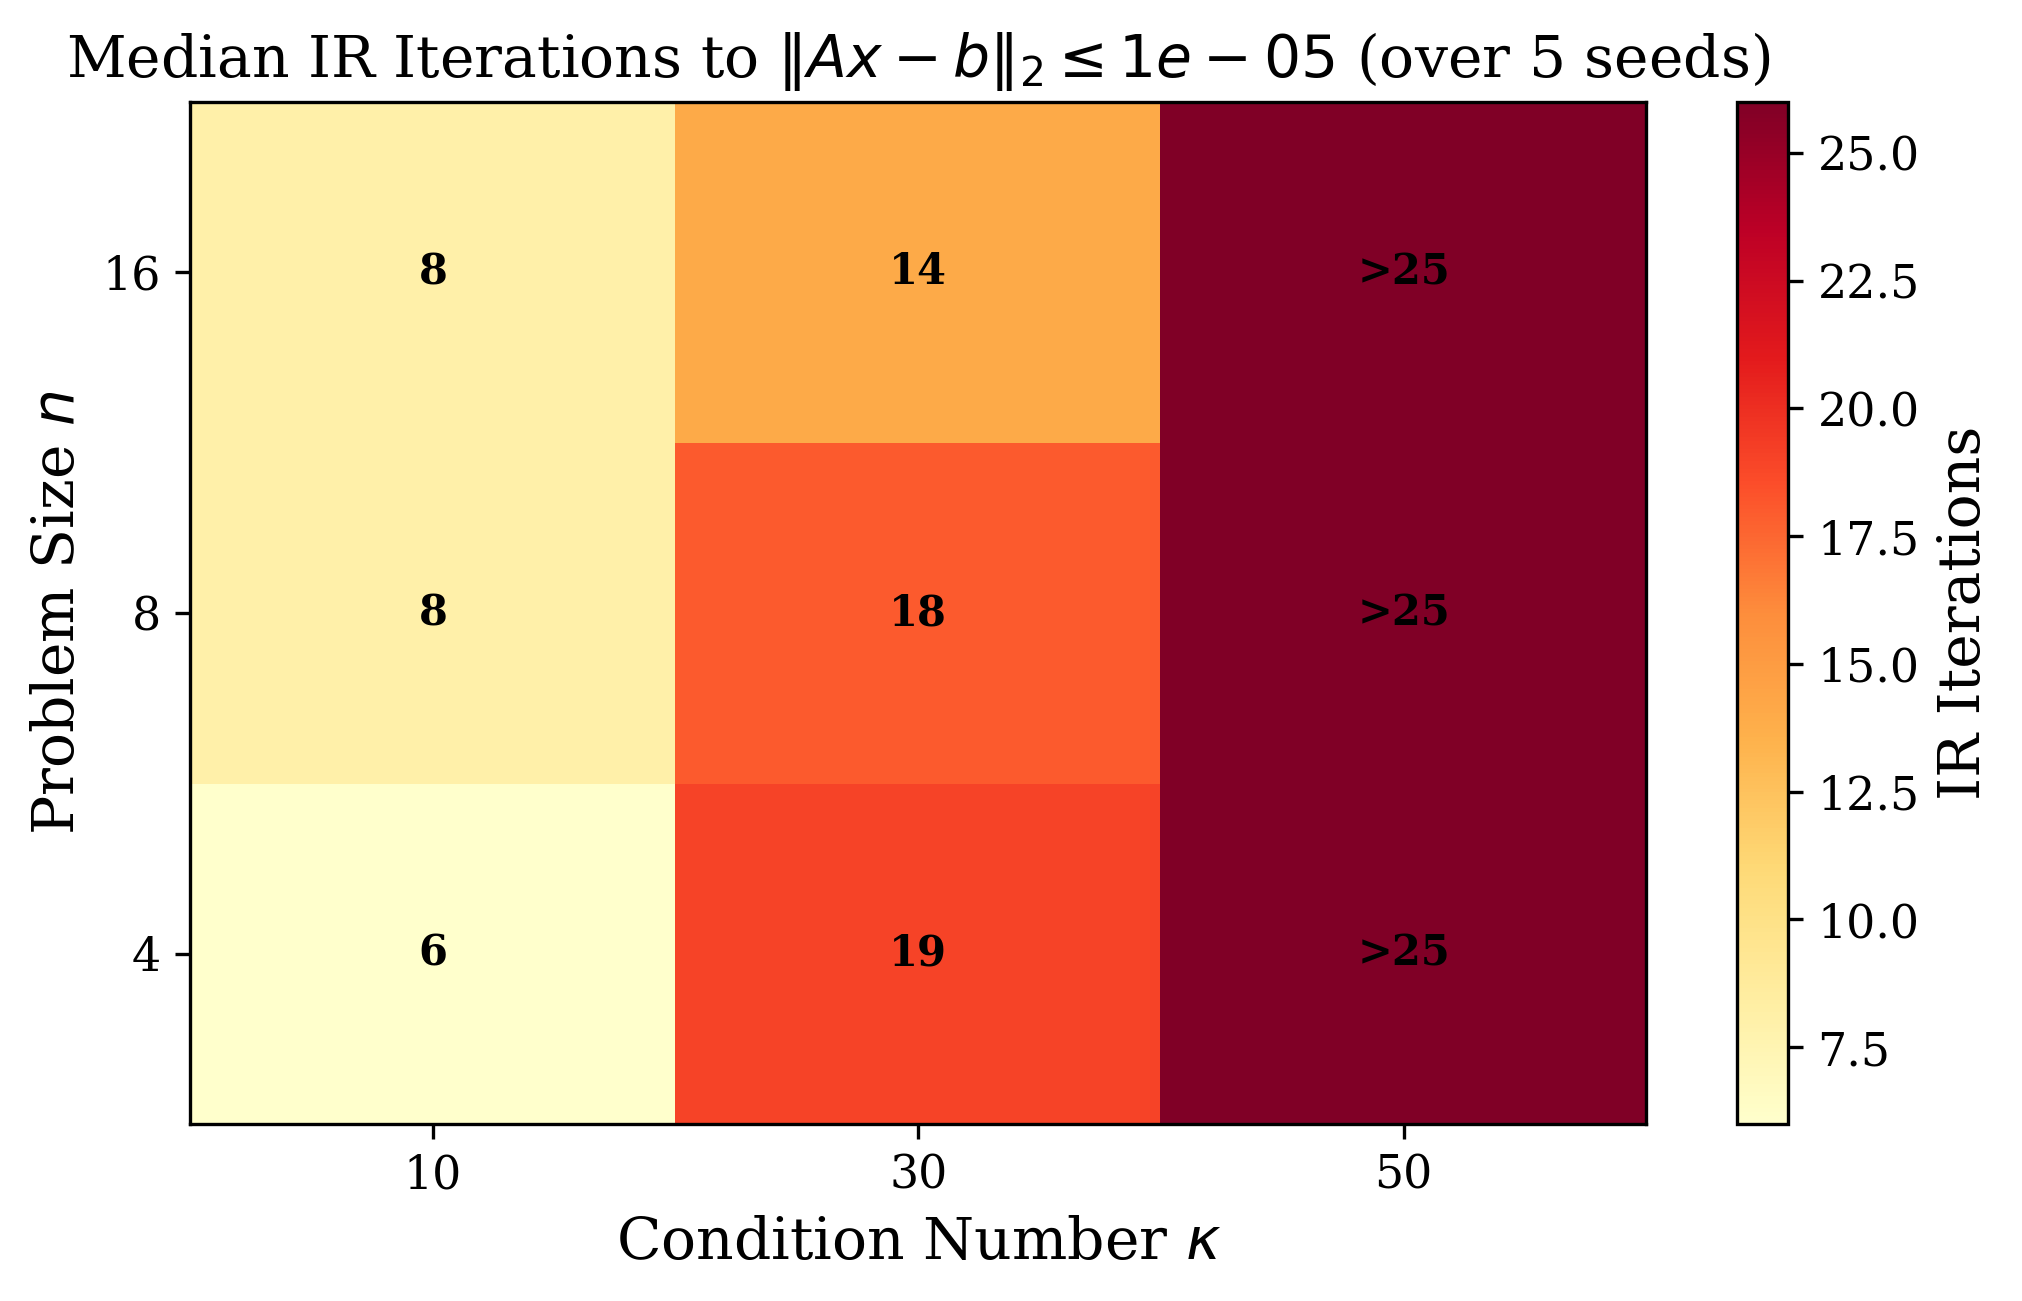

In [9]:
convergence_threshold = 1e-5

iters_grid = np.full((len(n_values), len(kappa_values), num_seeds), np.nan)
for i, n in enumerate(n_values):
    for j, kappa in enumerate(kappa_values):
        for s in range(num_seeds):
            iters_grid[i, j, s] = iterations_to_threshold(
                get_residuals(results, n, kappa, s), threshold=convergence_threshold
            )

median_iters = np.nanmedian(iters_grid, axis=2)

fig, ax = plt.subplots(figsize=(7, 4.5))
im = ax.imshow(
    median_iters,
    origin="lower",
    aspect="auto",
    cmap="YlOrRd",
    interpolation="nearest",
)

for i in range(len(n_values)):
    for j in range(len(kappa_values)):
        val = median_iters[i, j]
        label = f"{val:.0f}" if val < max_iter else f">{max_iter}"
        ax.text(j, i, label, ha="center", va="center", fontsize=10, fontweight="bold")

ax.set_xticks(range(len(kappa_values)))
ax.set_xticklabels([str(k) for k in kappa_values])
ax.set_yticks(range(len(n_values)))
ax.set_yticklabels([str(n) for n in n_values])
ax.set_xlabel(r"Condition Number $\kappa$")
ax.set_ylabel("Problem Size $n$")
ax.set_title(
    rf"Median IR Iterations to $\|Ax - b\|_2 \leq {convergence_threshold:.0e}$ (over {num_seeds} seeds)"
)

cbar = fig.colorbar(im, ax=ax)
cbar.set_label("IR Iterations")

plt.tight_layout()
plt.savefig(
    f"../data/sensitivity_heatmap_iters_{backend.name}_{datetime.now().strftime('%Y%m%d_%H%M%S')}.pdf"
)
plt.show()

### Circuit cost, gate counts, and post-selection probability

/var/folders/zv/92_qyn4s5v7f__ysxhlg_ykw0000gn/T/ipykernel_70502/2102969624.py:49: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


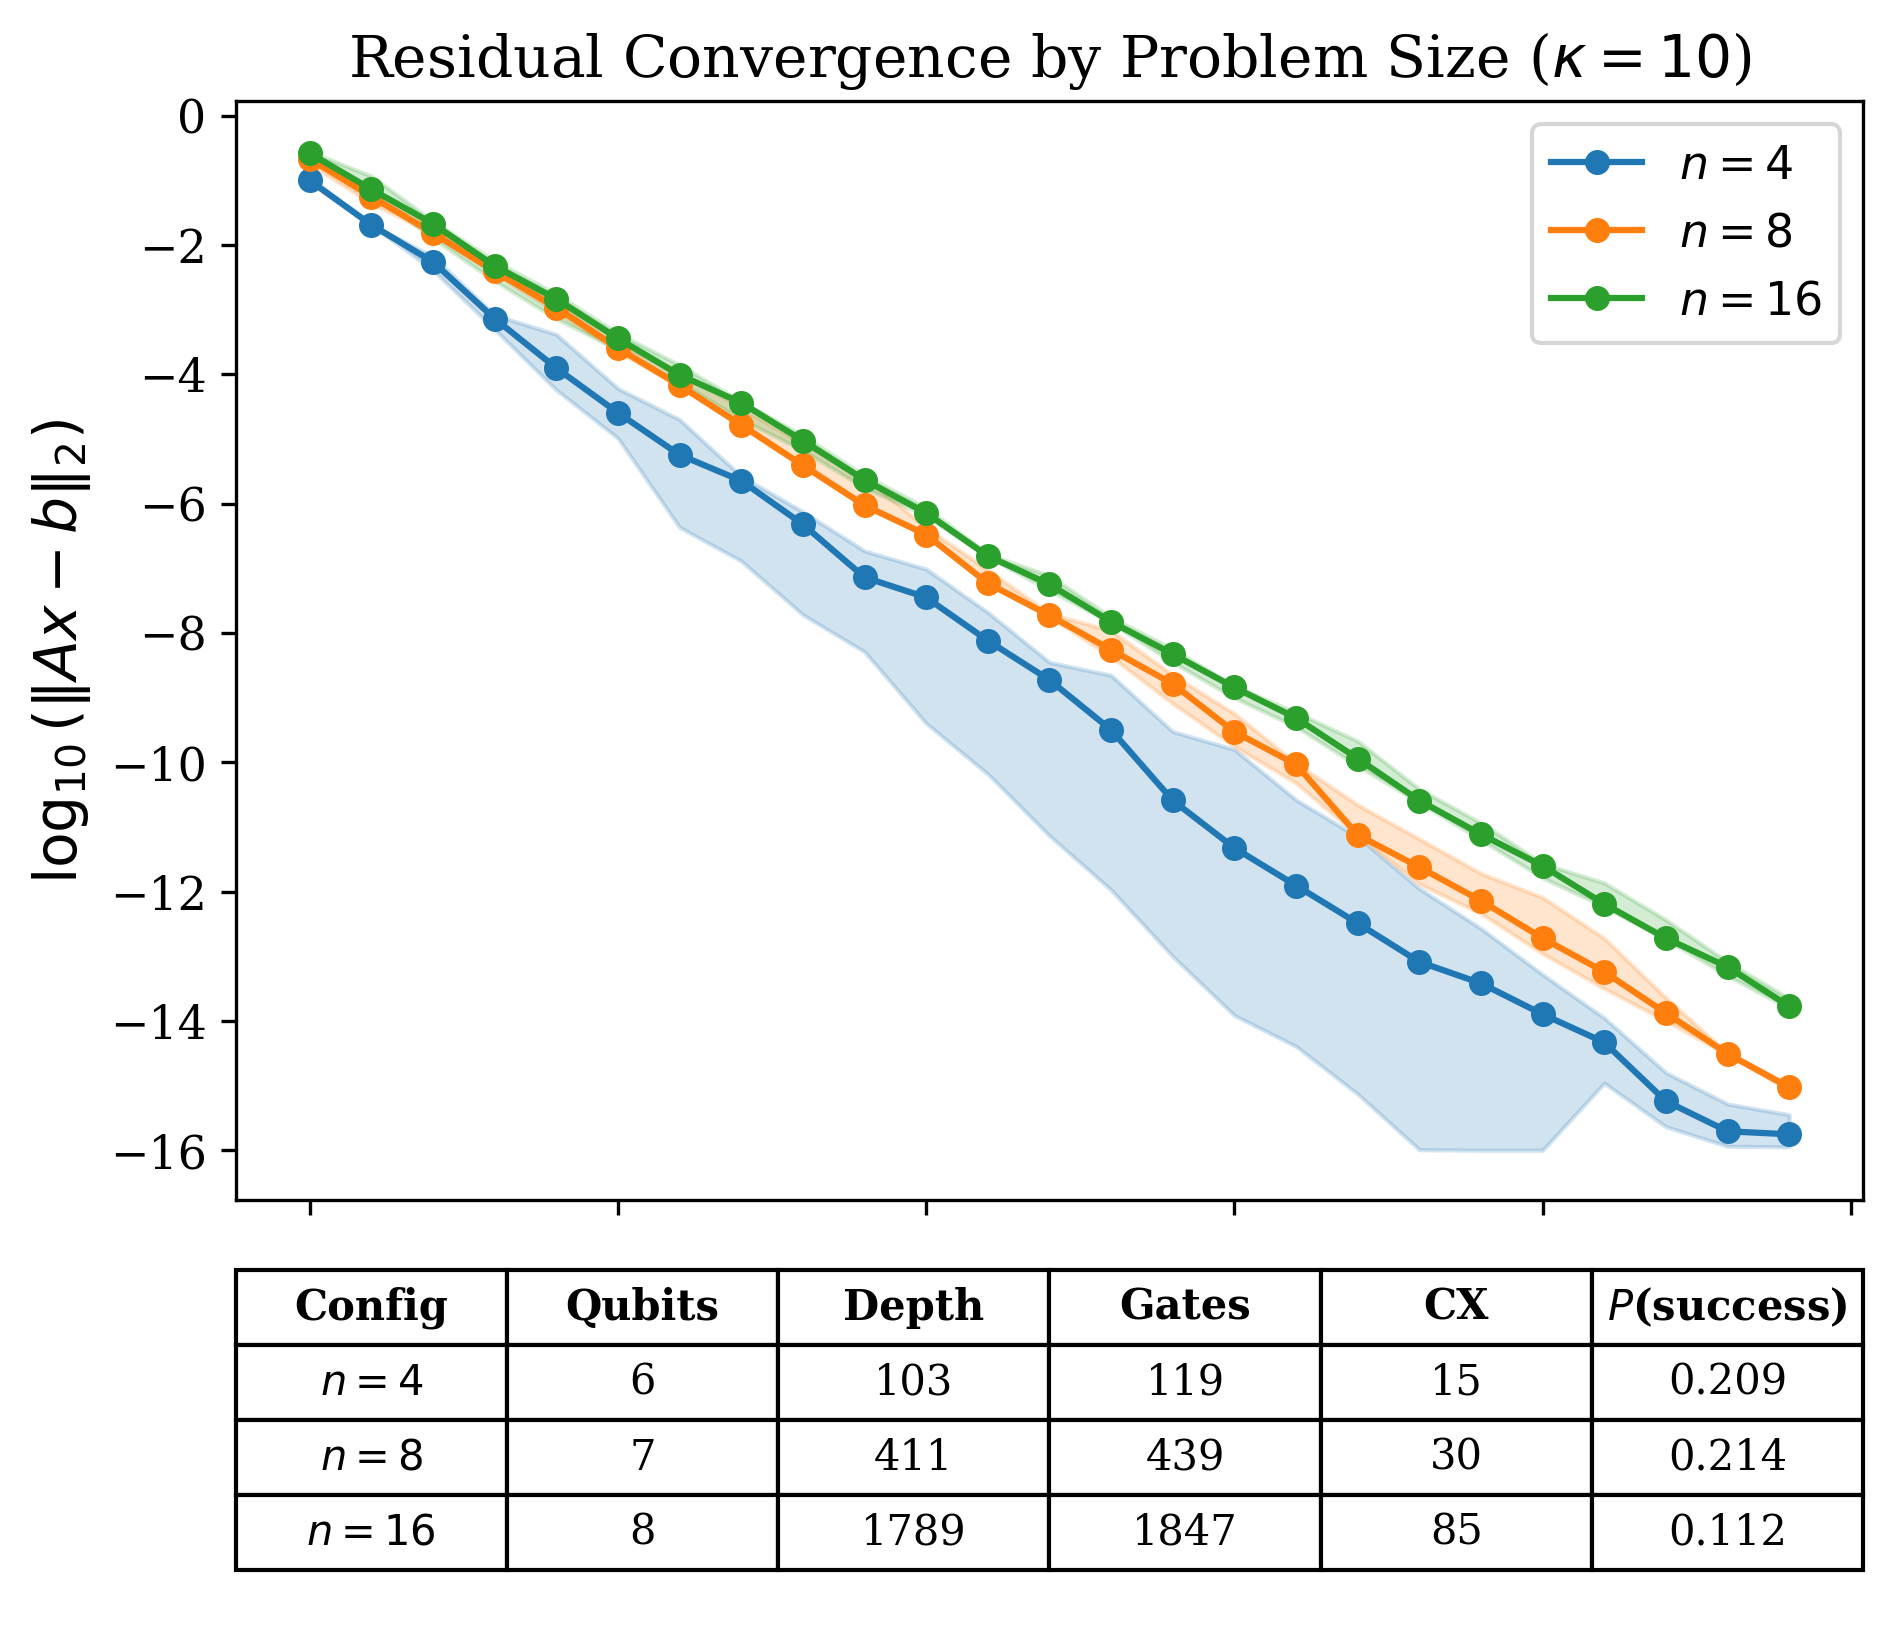

In [10]:
fixed_kappa_for_table = 10
size_subset_for_table = [4, 8, 16]

fig = plt.figure(figsize=(7, 6.5))
gs = fig.add_gridspec(2, 1, height_ratios=[3, 1], hspace=0.05)
ax = fig.add_subplot(gs[0])

table_rows = []
for n in size_subset_for_table:
    mat = get_log_residual_matrix(results, n, fixed_kappa_for_table, num_seeds, max_iter)
    median = np.nanmedian(mat, axis=0)
    q25 = np.nanpercentile(mat, 25, axis=0)
    q75 = np.nanpercentile(mat, 75, axis=0)
    iters = np.arange(max_iter)
    color = ax.plot(iters, median, "o-", label=f"$n = {n}$", markersize=5)[0].get_color()
    ax.fill_between(iters, q25, q75, alpha=0.2, color=color)

    depths = get_circuit_meta_matrix(results, n, fixed_kappa_for_table, num_seeds, max_iter, "depth")
    gates = get_circuit_meta_matrix(results, n, fixed_kappa_for_table, num_seeds, max_iter, "gate_count")
    cxs = get_circuit_meta_matrix(results, n, fixed_kappa_for_table, num_seeds, max_iter, "cx_count")
    qubits = get_circuit_meta_matrix(results, n, fixed_kappa_for_table, num_seeds, max_iter, "num_qubits")
    probs = get_success_prob_matrix(results, n, fixed_kappa_for_table, num_seeds, max_iter)

    table_rows.append([
        f"$n={n}$",
        f"{int(np.nanmedian(qubits))}",
        f"{np.nanmedian(depths):.0f}",
        f"{np.nanmedian(gates):.0f}",
        f"{np.nanmedian(cxs):.0f}",
        f"{np.nanmean(probs):.3f}",
    ])

ax.set_ylabel(r"$\log_{10}(\|Ax - b\|_2)$")
ax.set_title(rf"Residual Convergence by Problem Size ($\kappa = {fixed_kappa_for_table}$)")
ax.legend()
ax.set_xticklabels([])

ax_table = fig.add_subplot(gs[1])
ax_table.axis("off")
col_labels = ["Config", "Qubits", "Depth", "Gates", "CX", "$P$(success)"]
tbl = ax_table.table(cellText=table_rows, colLabels=col_labels, loc="center", cellLoc="center")
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1, 1.5)
for (row, col), cell in tbl.get_celld().items():
    if row == 0:
        cell.set_text_props(fontweight="bold")

plt.tight_layout()
plt.savefig(
    f"../data/sensitivity_size_with_table_{backend.name}_{datetime.now().strftime('%Y%m%d_%H%M%S')}.pdf"
)
plt.show()


/var/folders/zv/92_qyn4s5v7f__ysxhlg_ykw0000gn/T/ipykernel_70502/111936571.py:49: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


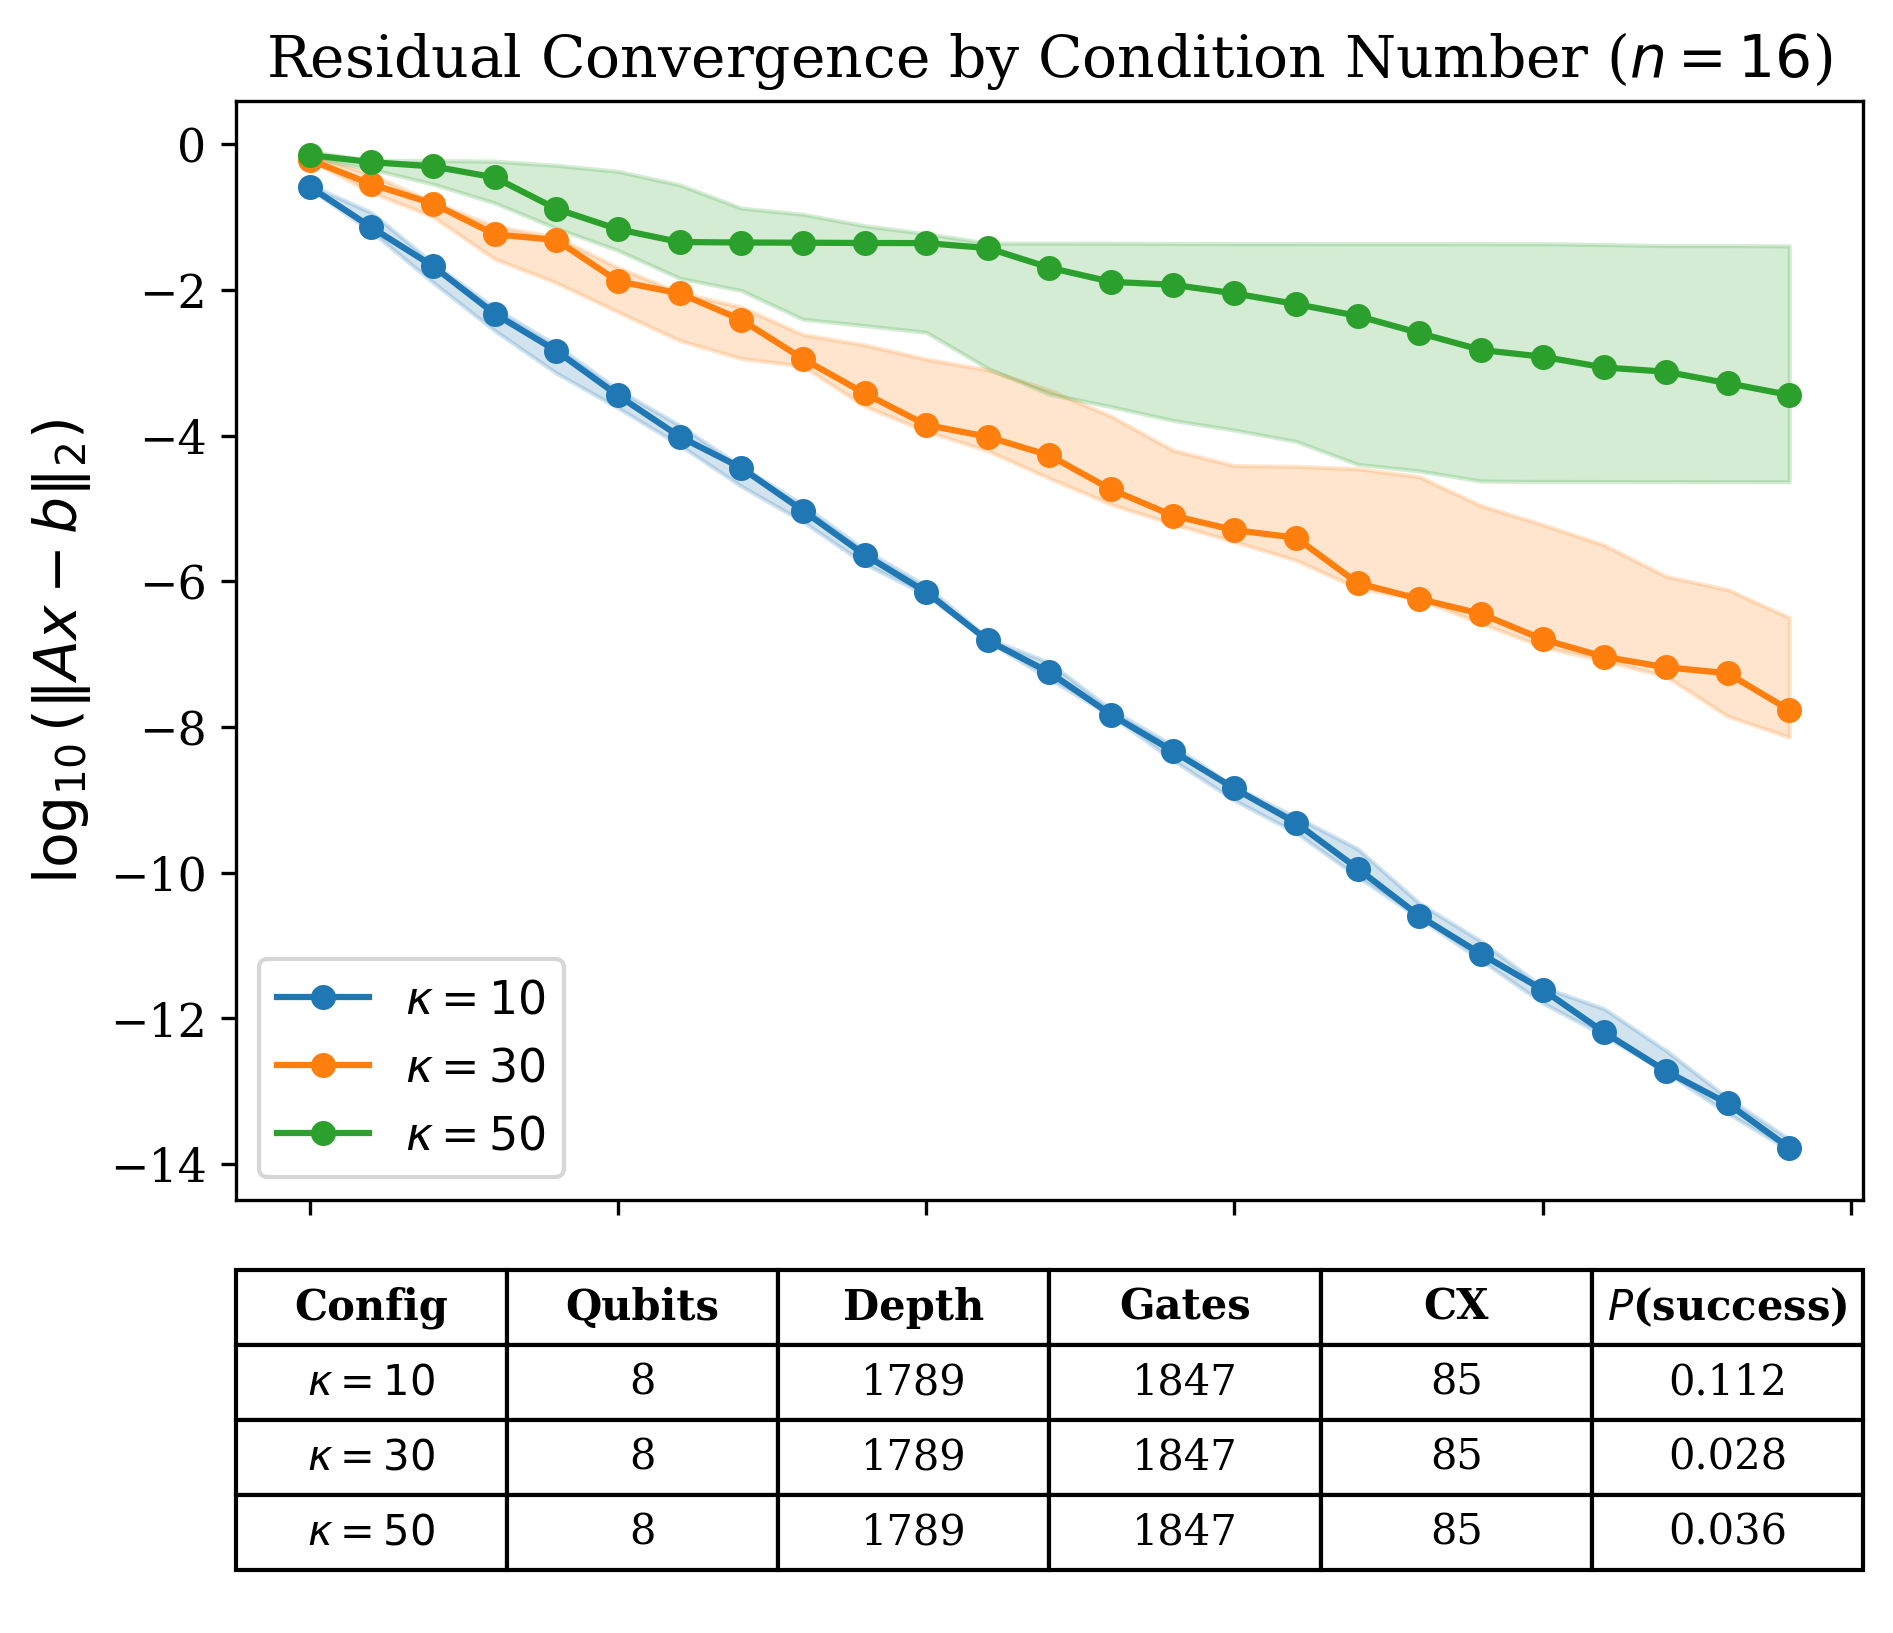

In [11]:
fixed_n_for_table = 16
kappa_subset_for_table = [10, 30, 50]

fig = plt.figure(figsize=(7, 6.5))
gs = fig.add_gridspec(2, 1, height_ratios=[3, 1], hspace=0.05)
ax = fig.add_subplot(gs[0])

table_rows = []
for kappa in kappa_subset_for_table:
    mat = get_log_residual_matrix(results, fixed_n_for_table, kappa, num_seeds, max_iter)
    median = np.nanmedian(mat, axis=0)
    q25 = np.nanpercentile(mat, 25, axis=0)
    q75 = np.nanpercentile(mat, 75, axis=0)
    iters = np.arange(max_iter)
    color = ax.plot(iters, median, "o-", label=rf"$\kappa = {kappa}$", markersize=5)[0].get_color()
    ax.fill_between(iters, q25, q75, alpha=0.2, color=color)

    depths = get_circuit_meta_matrix(results, fixed_n_for_table, kappa, num_seeds, max_iter, "depth")
    gates = get_circuit_meta_matrix(results, fixed_n_for_table, kappa, num_seeds, max_iter, "gate_count")
    cxs = get_circuit_meta_matrix(results, fixed_n_for_table, kappa, num_seeds, max_iter, "cx_count")
    qubits = get_circuit_meta_matrix(results, fixed_n_for_table, kappa, num_seeds, max_iter, "num_qubits")
    probs = get_success_prob_matrix(results, fixed_n_for_table, kappa, num_seeds, max_iter)

    table_rows.append([
        rf"$\kappa={kappa}$",
        f"{int(np.nanmedian(qubits))}",
        f"{np.nanmedian(depths):.0f}",
        f"{np.nanmedian(gates):.0f}",
        f"{np.nanmedian(cxs):.0f}",
        f"{np.nanmean(probs):.3f}",
    ])

ax.set_ylabel(r"$\log_{10}(\|Ax - b\|_2)$")
ax.set_title(rf"Residual Convergence by Condition Number ($n = {fixed_n_for_table}$)")
ax.legend()
ax.set_xticklabels([])

ax_table = fig.add_subplot(gs[1])
ax_table.axis("off")
col_labels = ["Config", "Qubits", "Depth", "Gates", "CX", "$P$(success)"]
tbl = ax_table.table(cellText=table_rows, colLabels=col_labels, loc="center", cellLoc="center")
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1, 1.5)
for (row, col), cell in tbl.get_celld().items():
    if row == 0:
        cell.set_text_props(fontweight="bold")

plt.tight_layout()
plt.savefig(
    f"../data/sensitivity_kappa_with_table_{backend.name}_{datetime.now().strftime('%Y%m%d_%H%M%S')}.pdf"
)
plt.show()


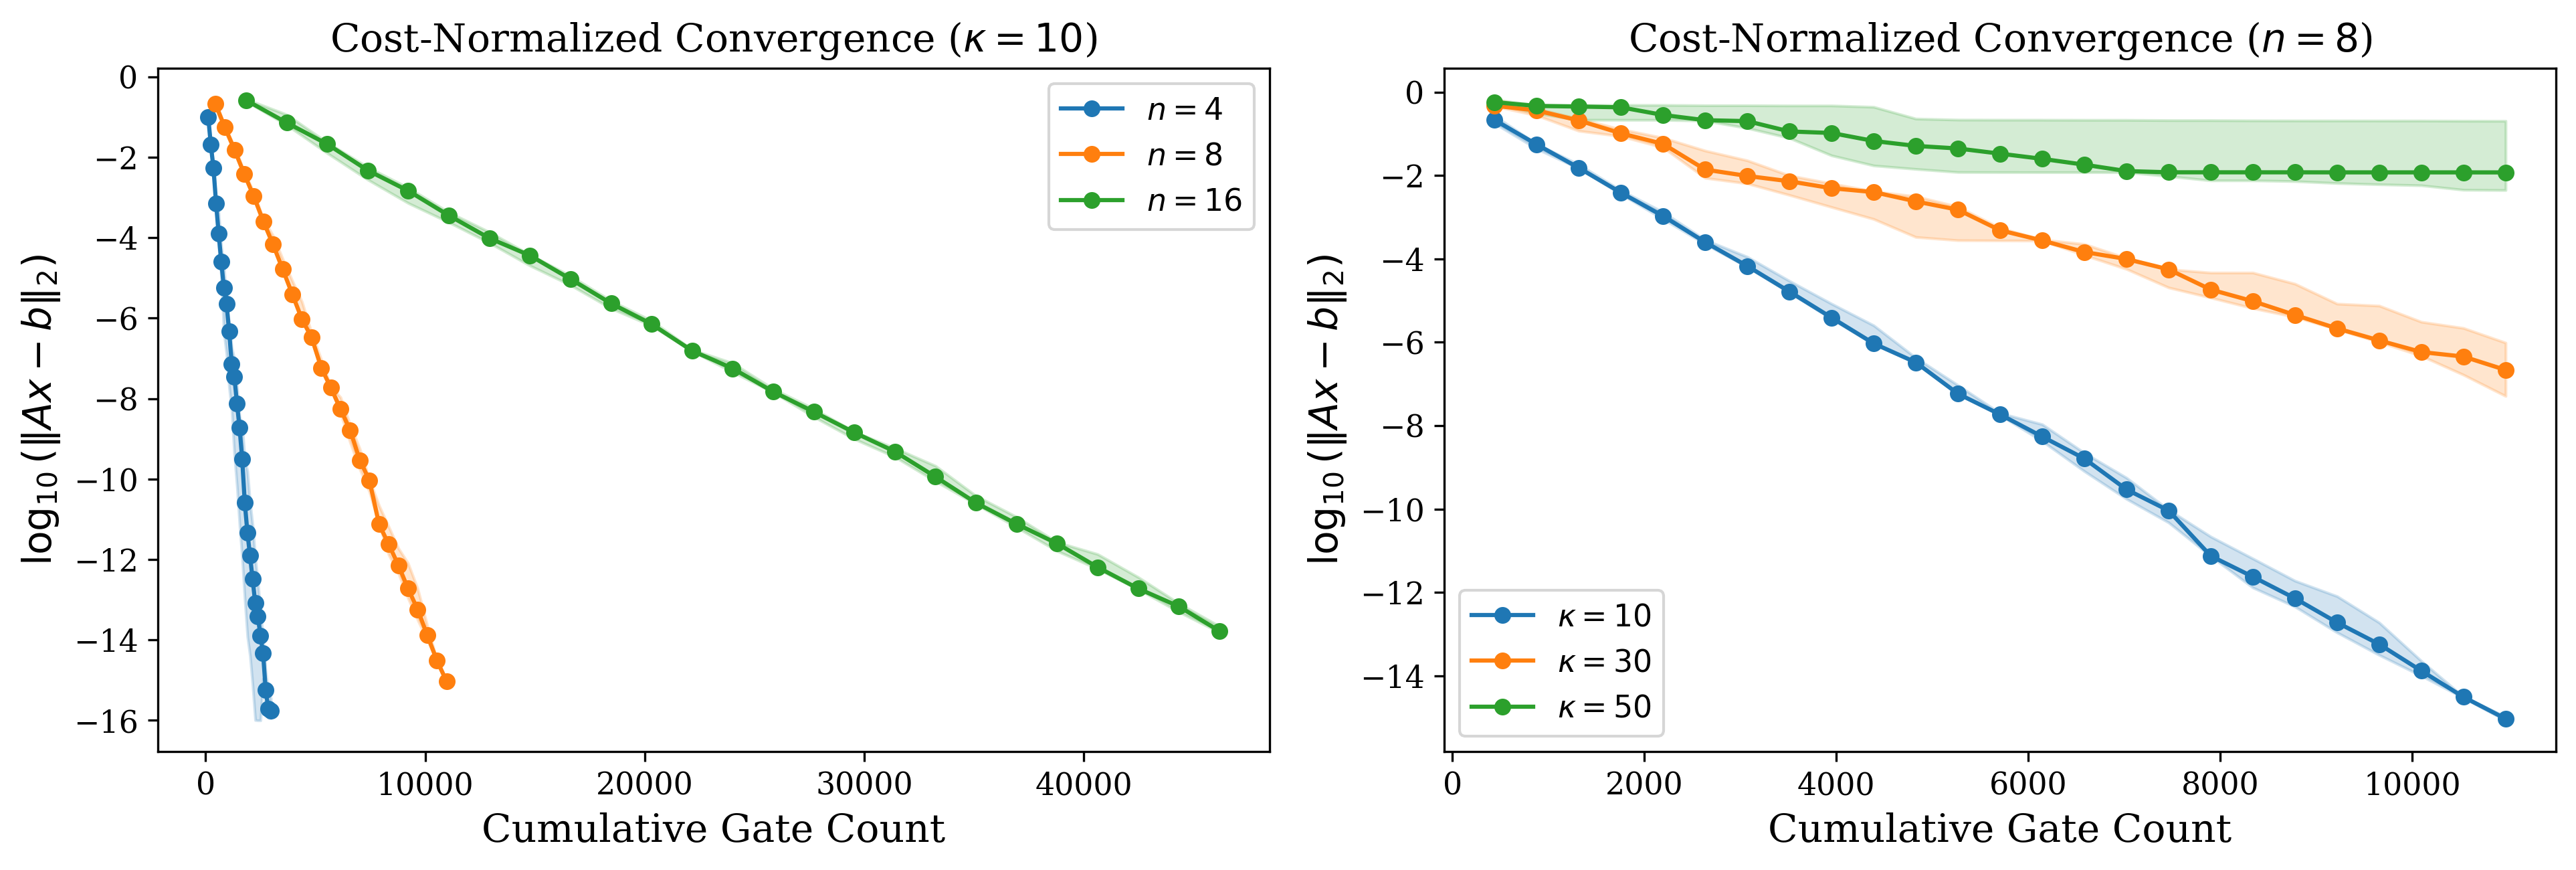

In [12]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))

# Left: residual vs cumulative gate count, varying problem size
cost_fixed_kappa = kappa_values[0]
for n in n_values:
    log_res = get_log_residual_matrix(results, n, cost_fixed_kappa, num_seeds, max_iter)
    gates = get_circuit_meta_matrix(results, n, cost_fixed_kappa, num_seeds, max_iter, "gate_count")
    cum_gates = np.nancumsum(gates, axis=1)
    median_res = np.nanmedian(log_res, axis=0)
    median_cost = np.nanmedian(cum_gates, axis=0)
    q25 = np.nanpercentile(log_res, 25, axis=0)
    q75 = np.nanpercentile(log_res, 75, axis=0)
    color = ax1.plot(median_cost, median_res, "o-", label=f"$n = {n}$", markersize=5)[0].get_color()
    ax1.fill_between(median_cost, q25, q75, alpha=0.2, color=color)

ax1.set_xlabel("Cumulative Gate Count")
ax1.set_ylabel(r"$\log_{10}(\|Ax - b\|_2)$")
ax1.set_title(rf"Cost-Normalized Convergence ($\kappa = {cost_fixed_kappa}$)")
ax1.legend()

# Right: residual vs cumulative gate count, varying condition number
cost_fixed_n = n_values[len(n_values) // 2]
kappa_sub = kappa_values[::2] if len(kappa_values) > 4 else kappa_values
for kappa in kappa_sub:
    log_res = get_log_residual_matrix(results, cost_fixed_n, kappa, num_seeds, max_iter)
    gates = get_circuit_meta_matrix(results, cost_fixed_n, kappa, num_seeds, max_iter, "gate_count")
    cum_gates = np.nancumsum(gates, axis=1)
    median_res = np.nanmedian(log_res, axis=0)
    median_cost = np.nanmedian(cum_gates, axis=0)
    q25 = np.nanpercentile(log_res, 25, axis=0)
    q75 = np.nanpercentile(log_res, 75, axis=0)
    color = ax2.plot(median_cost, median_res, "o-", label=rf"$\kappa = {kappa}$", markersize=5)[0].get_color()
    ax2.fill_between(median_cost, q25, q75, alpha=0.2, color=color)

ax2.set_xlabel("Cumulative Gate Count")
ax2.set_ylabel(r"$\log_{10}(\|Ax - b\|_2)$")
ax2.set_title(rf"Cost-Normalized Convergence ($n = {cost_fixed_n}$)")
ax2.legend()

plt.tight_layout()
plt.savefig(
    f"../data/sensitivity_cost_normalized_{backend.name}_{datetime.now().strftime('%Y%m%d_%H%M%S')}.pdf"
)
plt.show()


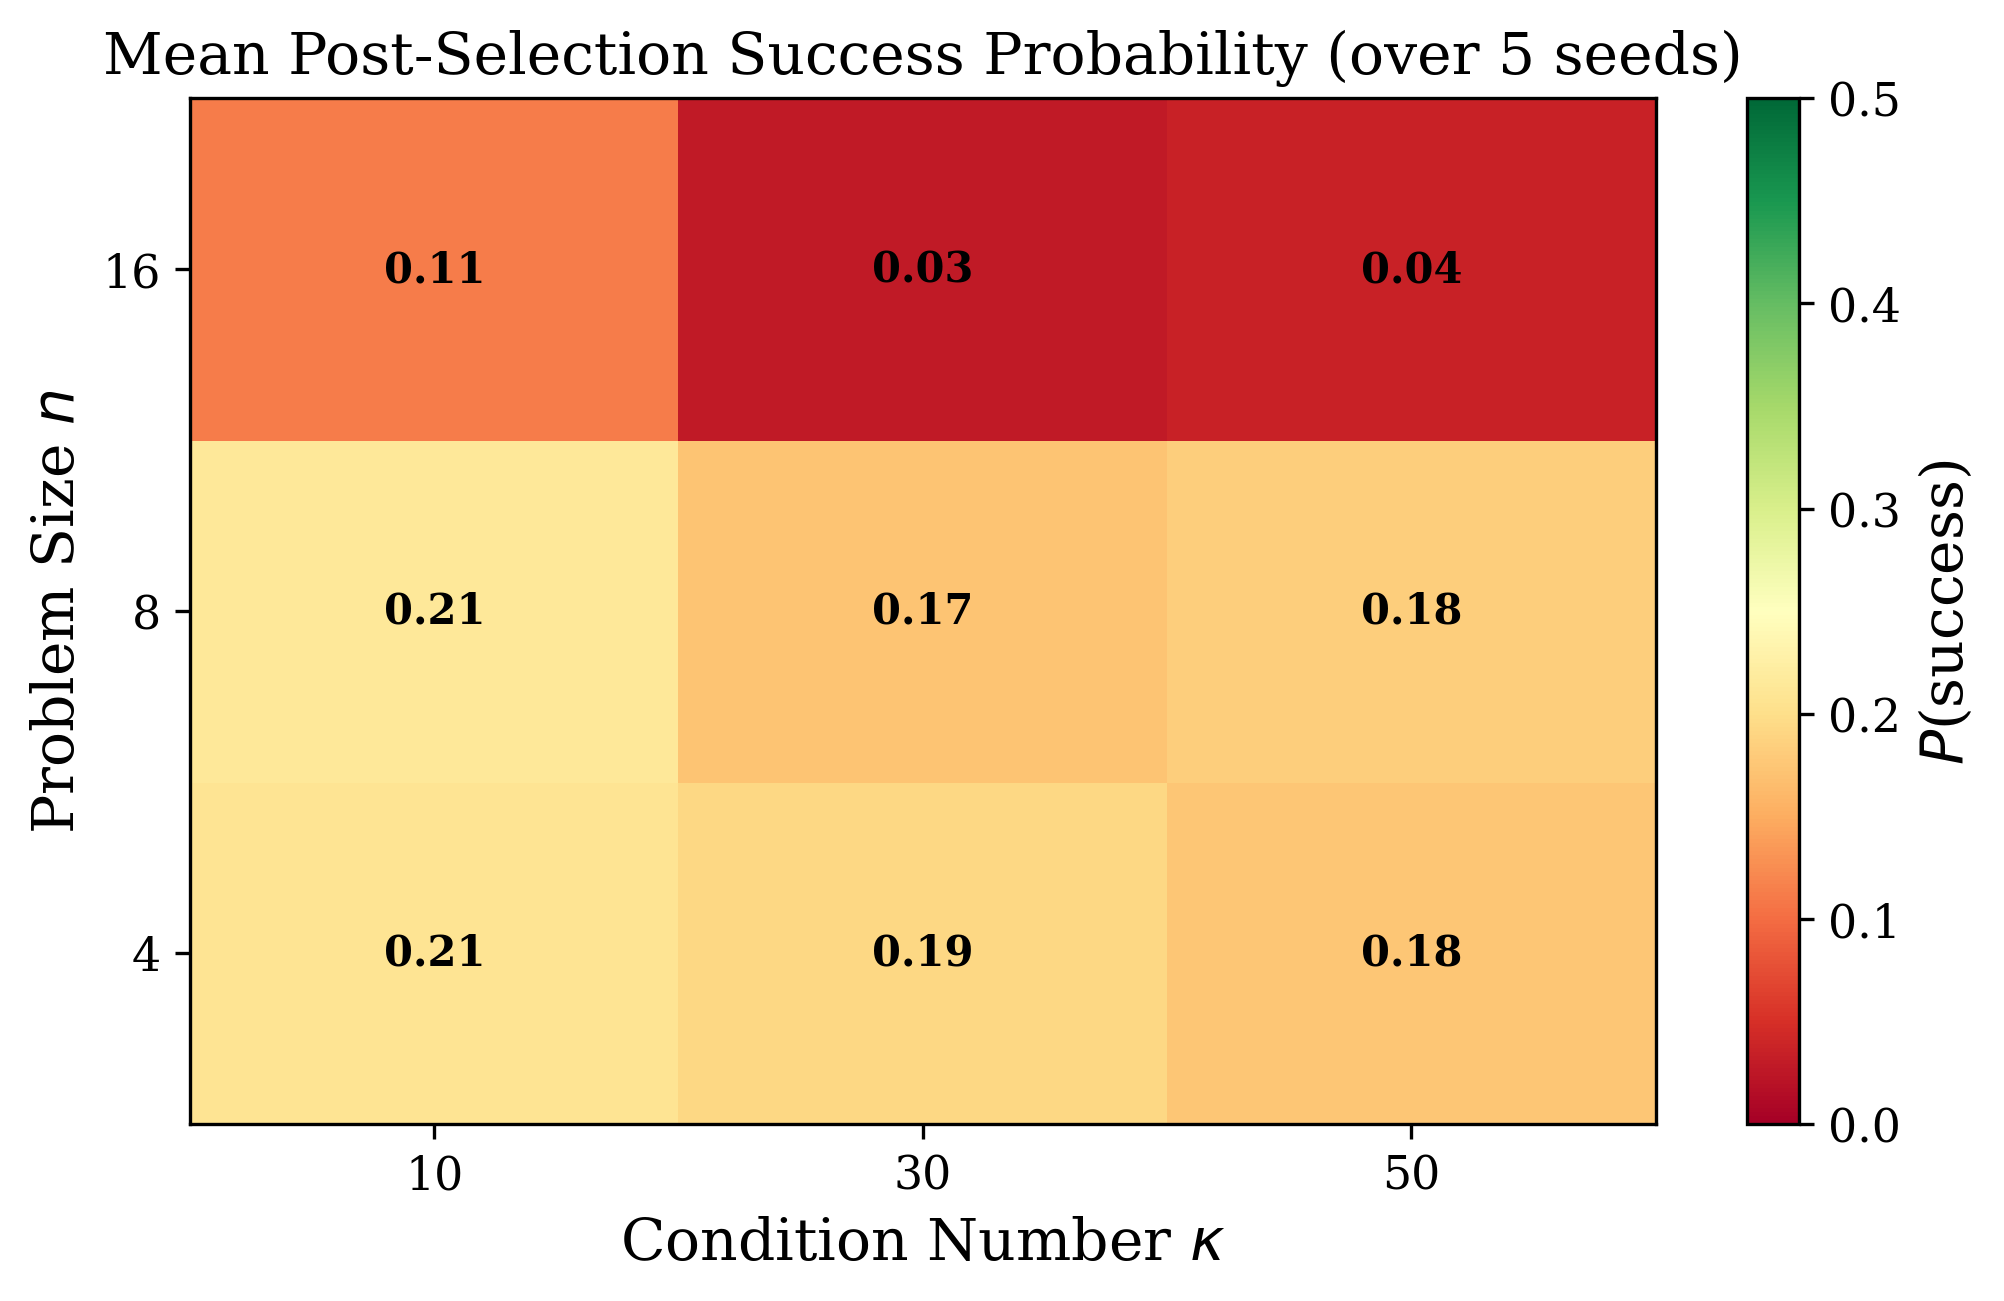

In [13]:
mean_prob = np.full((len(n_values), len(kappa_values)), np.nan)
for i, n in enumerate(n_values):
    for j, kappa in enumerate(kappa_values):
        probs = get_success_prob_matrix(results, n, kappa, num_seeds, max_iter)
        mean_prob[i, j] = np.nanmean(probs)

fig, ax = plt.subplots(figsize=(7, 4.5))
im = ax.imshow(
    mean_prob,
    origin="lower",
    aspect="auto",
    cmap="RdYlGn",
    interpolation="nearest",
    vmin=0,
    vmax=max(0.5, np.nanmax(mean_prob) * 1.1),
)

for i in range(len(n_values)):
    for j in range(len(kappa_values)):
        val = mean_prob[i, j]
        ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=10, fontweight="bold")

ax.set_xticks(range(len(kappa_values)))
ax.set_xticklabels([str(k) for k in kappa_values])
ax.set_yticks(range(len(n_values)))
ax.set_yticklabels([str(n) for n in n_values])
ax.set_xlabel(r"Condition Number $\kappa$")
ax.set_ylabel("Problem Size $n$")
ax.set_title(rf"Mean Post-Selection Success Probability (over {num_seeds} seeds)")

cbar = fig.colorbar(im, ax=ax)
cbar.set_label("$P$(success)")

plt.tight_layout()
plt.savefig(
    f"../data/sensitivity_success_prob_{backend.name}_{datetime.now().strftime('%Y%m%d_%H%M%S')}.pdf"
)
plt.show()


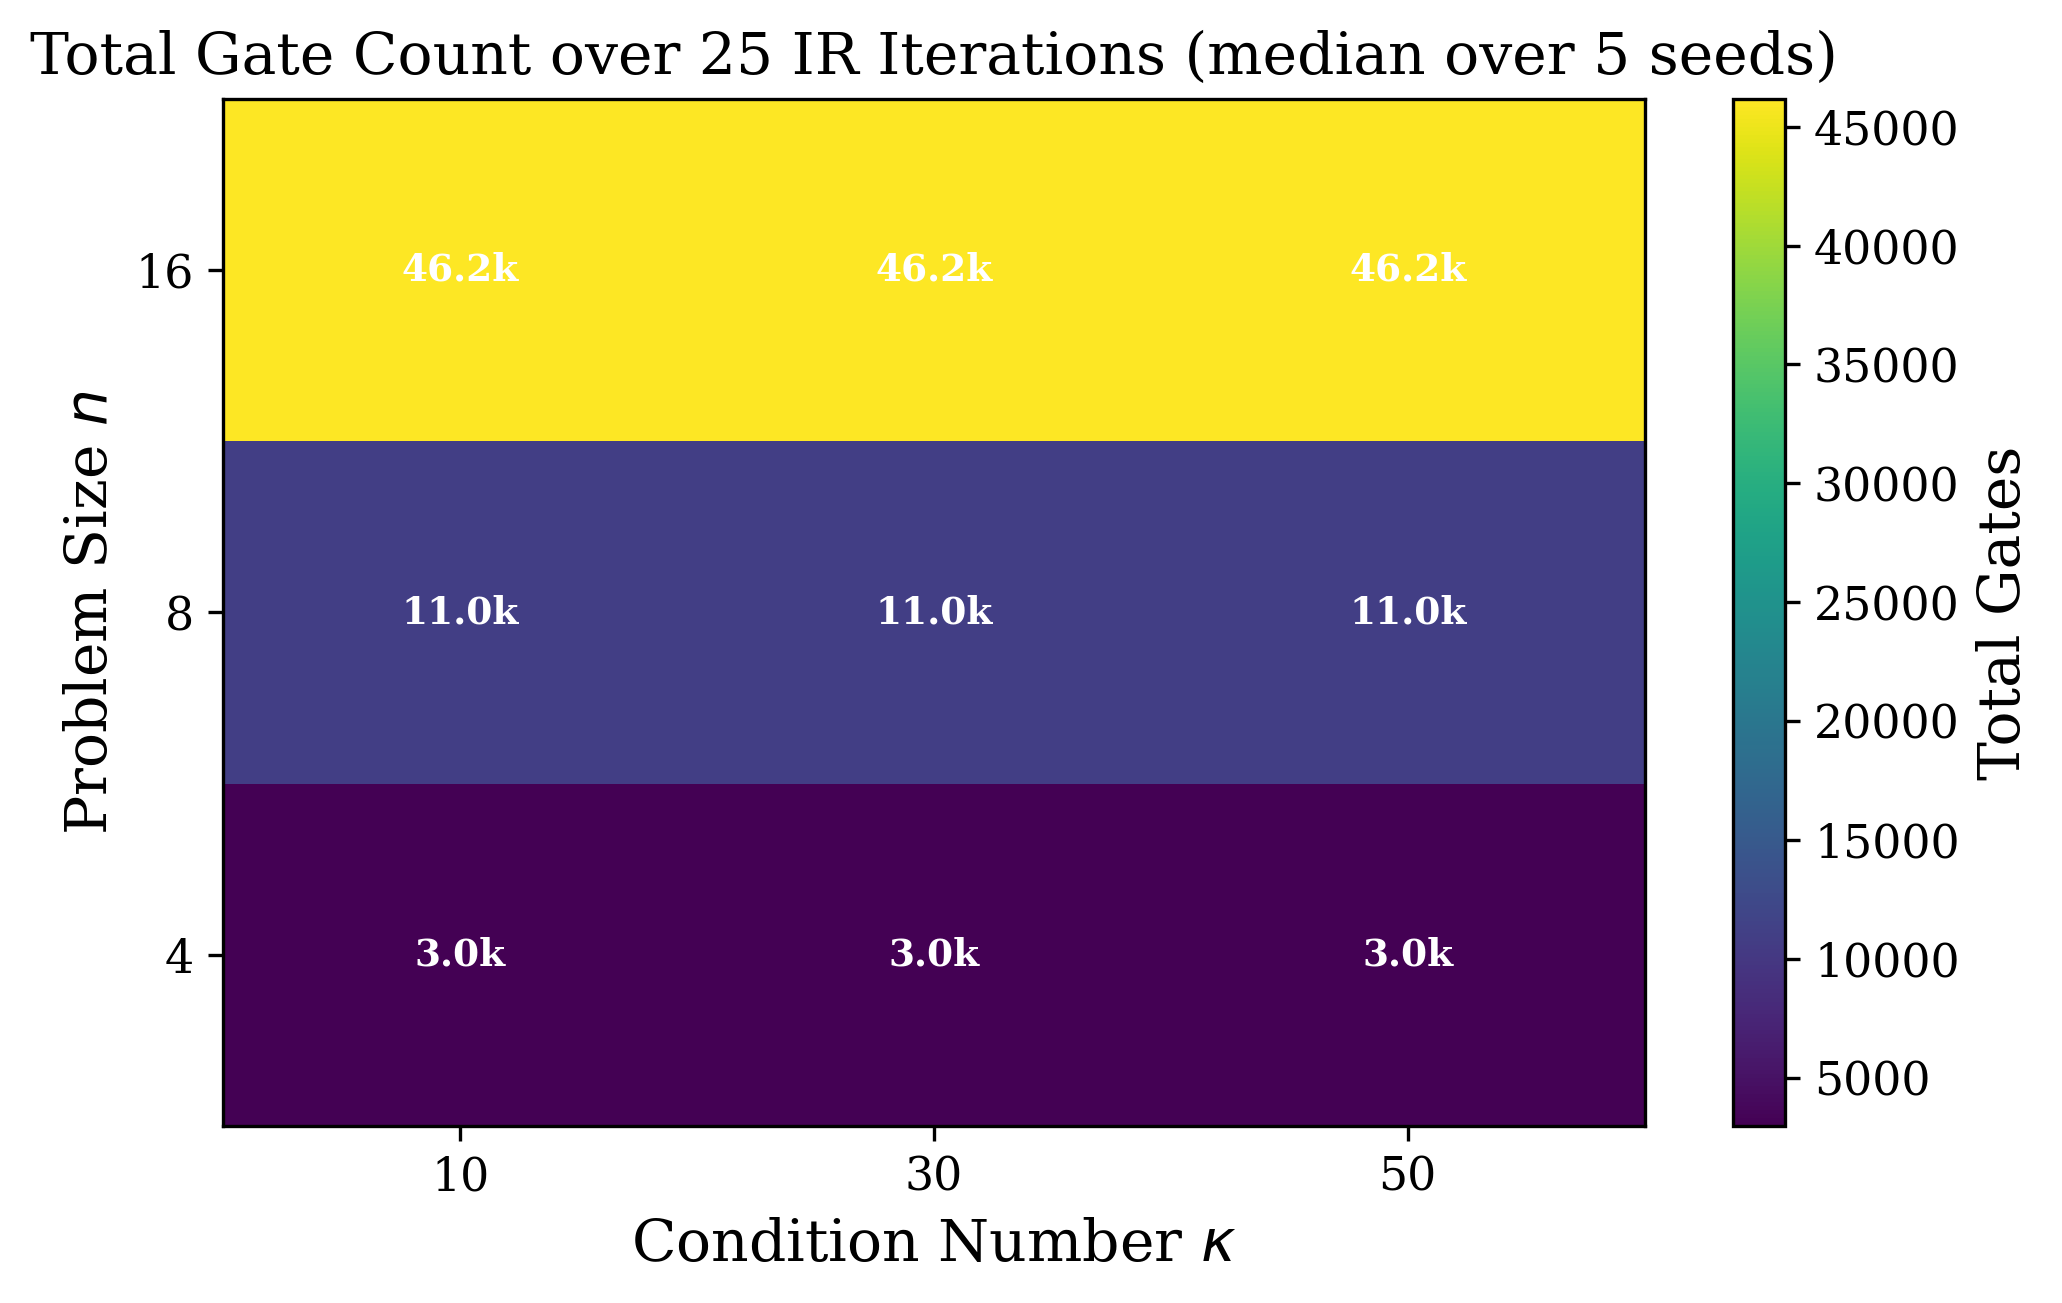

In [14]:
total_gates_grid = np.full((len(n_values), len(kappa_values)), np.nan)
for i, n in enumerate(n_values):
    for j, kappa in enumerate(kappa_values):
        gates = get_circuit_meta_matrix(results, n, kappa, num_seeds, max_iter, "gate_count")
        total_per_seed = np.nansum(gates, axis=1)
        total_gates_grid[i, j] = np.nanmedian(total_per_seed)

fig, ax = plt.subplots(figsize=(7, 4.5))
im = ax.imshow(
    total_gates_grid,
    origin="lower",
    aspect="auto",
    cmap="viridis",
    interpolation="nearest",
)

for i in range(len(n_values)):
    for j in range(len(kappa_values)):
        val = total_gates_grid[i, j]
        ax.text(j, i, f"{val/1000:.1f}k", ha="center", va="center",
                fontsize=9, fontweight="bold", color="white")

ax.set_xticks(range(len(kappa_values)))
ax.set_xticklabels([str(k) for k in kappa_values])
ax.set_yticks(range(len(n_values)))
ax.set_yticklabels([str(n) for n in n_values])
ax.set_xlabel(r"Condition Number $\kappa$")
ax.set_ylabel("Problem Size $n$")
ax.set_title(rf"Total Gate Count over {max_iter} IR Iterations (median over {num_seeds} seeds)")

cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Total Gates")

plt.tight_layout()
# plt.savefig(
#     f"../data/sensitivity_total_gates_{backend.name}_{datetime.now().strftime('%Y%m%d_%H%M%S')}.pdf"
# )
plt.show()


### HHL + IR vs. Direct HHL: Total circuit depth to reach target residual

Compares two strategies for solving an 8-variable system to $\|Ax - b\|_2 \leq 10^{-3}$, using the `8var_cond_sweep_cache` data:

- **HHL + IR (several QPE widths):** Repeated cheap HHL circuits via iterative refinement. Cumulative depth is data-driven from the sweep cache (`QPE_IR_LIST` in the code cell).
- **Direct HHL (no IR, extrapolated):** One-shot HHL at $q \geq \lceil \log_2(\kappa/\varepsilon)\rceil$ QPE qubits. **Depth** uses a **log-linear fit to a few transpiled circuits at high $q$** (default 10–14) on a fixed $n=8$ instance, saved as `data/direct_hhl_depth_calibration_n8.npz` — not a low-$q$ cache fit (which underestimates the QPE tail).



In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# HHL + IR vs. Direct HHL: circuit-depth cost to reach ‖Ax − b‖₂ ≤ THRESHOLD
#
# Data source: 8-variable cond-sweep cache (8var_cond_sweep_cache_*.npz)
#   residual_frames, depth_frames : per (κ, QPE level, IR iter)
#
# Line 1 – HHL + IR: cumulative depth until residual ≤ threshold (from cache).
# Line 2 – Direct HHL: depth(q_req) from log-linear fit on *transpiled* depths at high q
#   (default q = 10–14); see data/direct_hhl_depth_calibration_n8.npz
# ─────────────────────────────────────────────────────────────────────────────

THRESHOLD = 1e-6   # residual target
QPE_IR_LIST = [7,3,1]  # 1-based QPE qubit counts; each must be ≤ res_cs.shape[1]

# ── Load most recent 8-variable cond-sweep cache ─────────────────────────────
cs_candidates = sorted(
    (repo_root / "data").glob("8var_cond_sweep_cache_*.npz"),
    key=lambda p: p.stat().st_mtime,
)
if not cs_candidates:
    raise FileNotFoundError("No 8var_cond_sweep_cache_*.npz found in data/. "
                            "Run cond_sweep_animation.ipynb with n=8 first.")
cs_path = cs_candidates[-1]
cs = np.load(cs_path)
res_cs   = cs["residual_frames"]   # (21, 7, 30)
depth_cs = cs["depth_frames"]      # (21, 7, 30)  cumulative
kappa_cs = cs["kappa_measured"]    # (21,)
n_cs     = int(cs["n"][0])

print(f"Loaded: {cs_path.name}")
print(f"  n={n_cs}, κ ∈ [{kappa_cs.min():.0f}, {kappa_cs.max():.0f}], "
      f"QPE levels 1–{res_cs.shape[1]}, {res_cs.shape[2]} IR iterations")

# ── Line 1: HHL + IR cumulative depth to threshold ───────────────────────────
ir_curves = {}
for QPE_IR in QPE_IR_LIST:
    QPE_IDX = QPE_IR - 1
    if QPE_IDX < 0 or QPE_IDX >= res_cs.shape[1]:
        raise ValueError(
            f"QPE_IR={QPE_IR} out of range for cache (valid 1–{res_cs.shape[1]})"
        )
    ir_kappa, ir_depth = [], []
    for i, k in enumerate(kappa_cs):
        for it in range(res_cs.shape[2]):
            if res_cs[i, QPE_IDX, it] <= THRESHOLD:
                ir_kappa.append(float(k))
                ir_depth.append(float(depth_cs[i, QPE_IDX, it]))
                break  # first iteration that meets threshold
    ir_curves[QPE_IR] = (ir_kappa, ir_depth)
    if ir_kappa:
        print(
            f"\nHHL + IR (QPE={QPE_IR}) converged for {len(ir_kappa)}/{len(kappa_cs)} κ values "
            f"(κ = {ir_kappa[0]:.0f} – {ir_kappa[-1]:.0f})"
        )
    else:
        print(f"\nHHL + IR (QPE={QPE_IR}): no κ values reached threshold within cache.")

# ── Line 2: Direct HHL — extrapolate from measured transpiled depths (high-q) ──
from qlsas.transpiler import Transpiler

DIRECT_DEPTH_OPT_LEVEL = 0  # match calibration / AerSimulator diagnostic
DIRECT_DEPTH_CALIB_Q = np.array([5, 10, 15, 17], dtype=int)
DIRECT_DEPTH_CALIB_PATH = repo_root / "data" / "direct_hhl_depth_calibration_n8.npz"
# Set True once after changing DIRECT_DEPTH_CALIB_Q so the npz matches (Depth-vs-QPE cell reads the file)
RECALIBRATE_DIRECT_DEPTH = True  # True: re-transpile and overwrite cache (slow)

_prob_dd = generate_problem(n=8, cond_number=10.0, sparsity=0.5, seed=0)
_bnorm = np.linalg.norm(_prob_dd["b"])
_A_dd = _prob_dd["A"] / _bnorm
_b_dd = _prob_dd["b"] / _bnorm
_sp_dd = DefaultStatePrep()
_ro_dd = MeasureXReadout()


def _transpiled_depth_for_q(nq: int) -> float:
    hhl = HHL(num_qpe_qubits=int(nq), eig_oracle=ClassicalEigOracle())
    qlsa = hhl.build_circuit(_A_dd, _b_dd, _sp_dd)
    circ = _ro_dd.apply(qlsa, state_prep=_sp_dd)
    tp = Transpiler(
        circuit=circ, backend=backend, optimization_level=DIRECT_DEPTH_OPT_LEVEL
    ).optimize()
    return float(tp.depth())

if RECALIBRATE_DIRECT_DEPTH or not DIRECT_DEPTH_CALIB_PATH.exists():
    print(
        f"\nCalibrating Direct HHL depth ({len(DIRECT_DEPTH_CALIB_Q)} transpiled circuits, "
        f"opt_level={DIRECT_DEPTH_OPT_LEVEL})..."
    )
    _cal_q = np.asarray(DIRECT_DEPTH_CALIB_Q, dtype=int)
    _cal_d = np.array([_transpiled_depth_for_q(int(q)) for q in _cal_q], dtype=float)
    DIRECT_DEPTH_CALIB_PATH.parent.mkdir(parents=True, exist_ok=True)
    np.savez_compressed(
        DIRECT_DEPTH_CALIB_PATH,
        q=_cal_q,
        depth=_cal_d,
        opt_level=np.array([DIRECT_DEPTH_OPT_LEVEL], dtype=int),
    )
    print(f"  wrote {DIRECT_DEPTH_CALIB_PATH}")
else:
    _z = np.load(DIRECT_DEPTH_CALIB_PATH)
    _cal_q = np.asarray(_z["q"], dtype=int)
    _cal_d = np.asarray(_z["depth"], dtype=float)
    print(
        f"\nLoaded Direct HHL depth calibration (q = {_cal_q[0]}–{_cal_q[-1]}) "
        f"from {DIRECT_DEPTH_CALIB_PATH.name}"
    )

_log_slope, _log_intercept = np.polyfit(_cal_q, np.log(_cal_d), 1)
_gamma_fit = math.exp(_log_slope)
_A_fit = math.exp(_log_intercept)

print(f"\nDepth model (log-linear fit on transpiled depths):")
print(f"  depth(q) ≈ {_A_fit:.4g} × {_gamma_fit:.4f}^q")
print(f"  Calibration (measured vs fitted):")
for q, d in zip(_cal_q, _cal_d):
    print(f"    QPE={int(q)}: measured={d:.0f},  fitted={_A_fit * _gamma_fit ** q:.0f}")


def _direct_hhl_depth(kappa: float, epsilon: float = THRESHOLD) -> float:
    """Single-shot HHL depth from high-q transpiled calibration (extrapolated in q)."""
    q_req = max(math.ceil(math.log2(kappa / epsilon)), 1)
    return _A_fit * (_gamma_fit ** q_req)

direct_kappa = kappa_cs
direct_depth = [_direct_hhl_depth(k) for k in direct_kappa]
q_per_kappa = [
    max(math.ceil(math.log2(float(k) / THRESHOLD)), 1) for k in direct_kappa
]

print(f"\nDirect HHL depth range:  {min(direct_depth):.3g} – {max(direct_depth):.3g}")
for QPE_IR in QPE_IR_LIST:
    _ik, _id = ir_curves[QPE_IR]
    if _ik:
        print(
            f"HHL + IR (QPE={QPE_IR}) depth range:   {min(_id):.0f} – {max(_id):.0f}"
        )

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5))
ax.set_yscale("log")

staircase = {}
for q, d in zip(q_per_kappa, direct_depth):
    if q not in staircase:
        staircase[q] = d
for q in sorted(staircase):
    ax.axhline(
        staircase[q], color="grey", linestyle=":", linewidth=0.75, alpha=0.45, zorder=1
    )

# Paul Tol "Bright" / "Vibrant"–style colors (colorblind-safe, higher chroma than Okabe–Ito)
# Ref: https://personal.sron.nl/~pault/ — orange reserved for Direct HHL
_COLOR_DIRECT_HHL = "#EE7733"
# Hues spaced across the wheel (no blue–cyan–teal run); Paul Tol–style hexes
_COLORS_IR_TOL = np.array(
    [
        "#0077BB",  # blue
        "#CC3311",  # red
        "#CCBB44",  # yellow (Tol bright)
        "#009988",  # teal
        "#EE3377",  # magenta
        "#AA3377",  # purple
    ]
)
_colors_ir = _COLORS_IR_TOL[np.arange(len(QPE_IR_LIST)) % len(_COLORS_IR_TOL)]
for _j, QPE_IR in enumerate(QPE_IR_LIST):
    _ik, _id = ir_curves[QPE_IR]
    if not _ik:
        continue
    ax.plot(
        _ik,
        _id,
        "o-",
        label=f"HHL + IR  (QPE = {QPE_IR} qubits)" if QPE_IR != 1 else f"HHL + IR  (QPE = {QPE_IR} qubit)",
        markersize=5,
        linewidth=1.25,
        markerfacecolor="white",
        markeredgewidth=0.9,
        color=_colors_ir[_j],
        zorder=3,
    )

ax.plot(
    direct_kappa,
    direct_depth,
    "s--",
    label="Direct HHL  (no IR)",
    markersize=4.5,
    linewidth=1.35,
    color=_COLOR_DIRECT_HHL,
    zorder=2,
)

# Labels on each Direct-HHL plateau
plateaus = []
_run_lo = 0
for i in range(1, len(q_per_kappa)):
    if q_per_kappa[i] != q_per_kappa[i - 1]:
        plateaus.append((_run_lo, i - 1, q_per_kappa[i - 1]))
        _run_lo = i
plateaus.append((_run_lo, len(q_per_kappa) - 1, q_per_kappa[-1]))

for i_lo, i_hi, q in plateaus:
    k_lo = float(direct_kappa[i_lo])
    k_hi = float(direct_kappa[i_hi])
    d = float(direct_depth[i_lo])
    x_mid = 0.5 * (k_lo + k_hi)
    # Log y: offset in points keeps labels just above the plateau; bbox + clip keeps them readable
    ax.annotate(
        rf"$q = {q}$ QPE qubits",
        xy=(x_mid, d),
        xytext=(0, 8),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=9,
        color="0.15",
        annotation_clip=False,
        bbox={
            "boxstyle": "round,pad=0.35",
            "facecolor": "white",
            "edgecolor": _COLOR_DIRECT_HHL,
            "linewidth": 0.9,
            "alpha": 0.94,
        },
        zorder=6,
    )

# HHL+IR non-convergence shading (disabled; with QPE_IR_LIST use ir_curves[QPE_IR] per series)
# kappa_max = float(kappa_cs[-1])
# if len(ir_kappa) < len(kappa_cs):
#     ax.axvspan(ir_kappa[-1], kappa_max,
#                alpha=0.10, color="tab:blue",
#                label=f"HHL + IR did not converge\n(within {res_cs.shape[2]} iterations)")

ax.set_xlabel(r"Condition Number $\kappa$", fontsize=13)
ax.set_ylabel("Cumulative Circuit Depth", fontsize=13)
ax.set_title(f"Threshold = {THRESHOLD:.0e}", fontsize=11)
ax.legend(fontsize=10, loc="best")
ax.grid(True, which="both", alpha=0.3)
ax.margins(y=0.08)
plt.tight_layout()
plt.savefig(
    f"../data/sensitivity_total_gates_IR_vs_direct.pdf"
)
plt.show()

Loaded: 8var_cond_sweep_cache_20260407_201250.npz
  n=8, κ ∈ [10, 50], QPE levels 1–7, 30 IR iterations

HHL + IR (QPE=7) converged for 21/21 κ values (κ = 10 – 50)

HHL + IR (QPE=3) converged for 12/21 κ values (κ = 10 – 32)

HHL + IR (QPE=1) converged for 3/21 κ values (κ = 10 – 14)

Calibrating Direct HHL depth (4 transpiled circuits, opt_level=0)...


### Test: depth vs QPE qubits (n = 8)

Loads **`data/direct_hhl_depth_calibration_n8.npz`** from the previous cell (run that cell first). Plots the **fitted** depth curve and **measured** transpiled depths at calibration $q$.


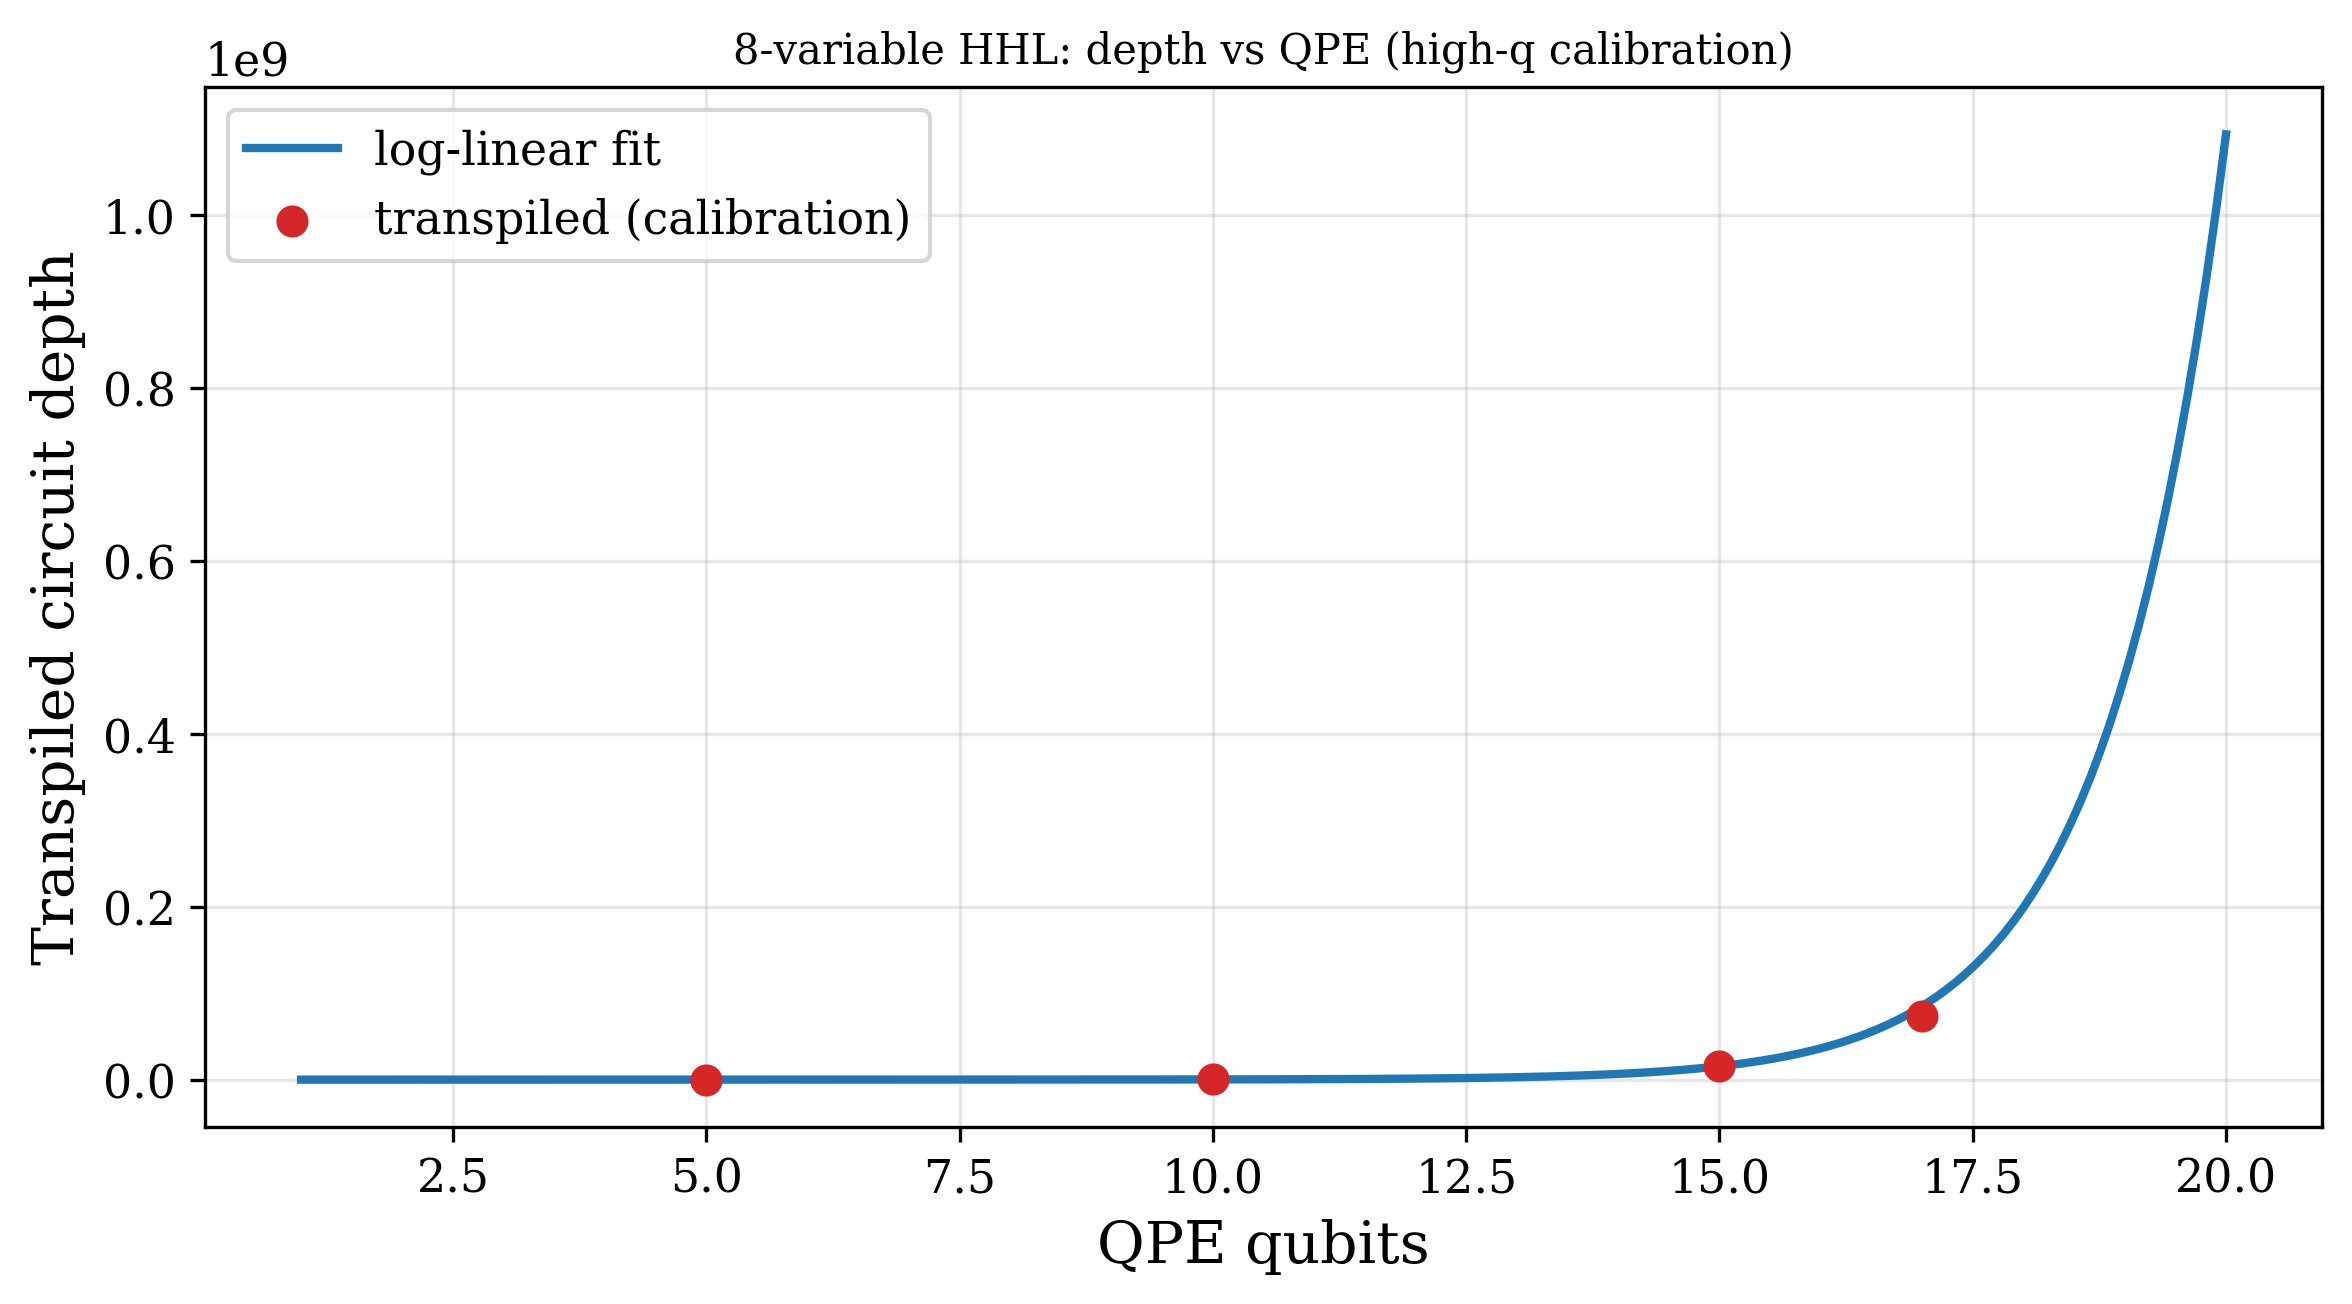

Fit: depth(q) ≈ 43.62 × 2.3440^q


In [ ]:
# Depth vs QPE — same calibration file as Direct HHL staircase (previous cell).
# DIRECT_DEPTH_CALIB_Q must match the IR-vs-Direct cell; the npz stores whatever
# was last written there (recalibrate if you change the grid).
DIRECT_DEPTH_CALIB_Q = np.array([5, 10, 15, 17], dtype=int)
DIRECT_DEPTH_CALIB_PATH = repo_root / "data" / "direct_hhl_depth_calibration_n8.npz"

if not DIRECT_DEPTH_CALIB_PATH.exists():
    raise FileNotFoundError(
        f"Missing {DIRECT_DEPTH_CALIB_PATH.name}. Run the previous cell once to build calibration."
    )

z = np.load(DIRECT_DEPTH_CALIB_PATH)
cal_q = np.asarray(z["q"], dtype=float)
_cal_q_file = np.asarray(z["q"], dtype=int).ravel()
_stale = not np.array_equal(_cal_q_file, DIRECT_DEPTH_CALIB_Q)
if _stale:
    print("\n" + "=" * 72)
    print("  STALE direct_hhl_depth_calibration_n8.npz (plot uses on-disk q, not the code grid)")
    print(f"  File q:   {_cal_q_file.tolist()}")
    print(f"  Expected: {DIRECT_DEPTH_CALIB_Q.tolist()}  (must match IR-vs-Direct cell)")
    print("  Fix: run the **HHL + IR vs Direct HHL** cell with")
    print("       RECALIBRATE_DIRECT_DEPTH = True   → then re-run this cell.")
    print("=" * 72 + "\n")
cal_d = np.asarray(z["depth"], dtype=float)
_log_slope, _log_intercept = np.polyfit(cal_q, np.log(cal_d), 1)
A_fit = float(np.exp(_log_intercept))
gamma_fit = float(np.exp(_log_slope))

q_fine = np.linspace(1, 20, 200)
depth_fine = A_fit * (gamma_fit ** q_fine)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(q_fine, depth_fine, color="tab:blue", linewidth=2, label="log-linear fit")
ax.scatter(cal_q, cal_d, color="tab:red", s=45, zorder=5, label="transpiled (calibration)")
ax.set_xlabel("QPE qubits")
ax.set_ylabel("Transpiled circuit depth")
_ttl = "8-variable HHL: depth vs QPE (high-q calibration)"
if _stale:
    _ttl += f"\n(stale: file q={_cal_q_file.tolist()}; rerun IR cell with RECALIBRATE_DIRECT_DEPTH=True)"
ax.set_title(_ttl, fontsize=10)
ax.legend(loc="upper left")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Fit: depth(q) ≈ {A_fit:.4g} × {gamma_fit:.4f}^q")
